<h1>Food-tech startup</h1>


<h3>Company mission</h3>

<p>
From the website:<br>
"Our Food-tech startup company was founded in 2020 in the midst of the Covid Pandemic. The world wanted
inspiration so we decided to provide it. We started life as a search engine for recipes, helping
people to find ways to use up the limited supplies they had at home.
Now, over two years on, we are a fully fledged business. For a monthly subscription we will put
together a full meal plan to ensure you and your family are getting a healthy, balanced diet whatever your budget. Subscribe to our premium plan and we will also deliver the ingredients
to your door."
</p>

<h3>Data Science Task</h3>

<p>
The task is to suggest recipes we should display on the home
page. At the moment the recipe is choosen by intuition.
The traffic to the rest of the website goes up by as much as 40% if a
a popular recipe is picked. 
Predicting which recipes will be popular 80% of the time and minimize the
chance of showing unpopular recipes is the goal of the Data Science project.
</p>




## 📝 Task List


The written report should include both code, output and written text summaries of the following:
- Section 1: Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Section 2: Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Section 3: Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Section 4: Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Section 5: Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Section 6: Final summary including recommendations that the business should undertake
<hr style="width:50%;text-align:left;margin-left:0"> 
<p>
The report is structured into two parts. The first part is the Data Science report, including code and visualisations. The second part is the business report, including the business metric and recommendations. The report starts with a management summary
</p>
__

In [215]:

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import matplotlib as mpl
from cycler import cycler

import pandas as pd
import numpy as np
import os as os
import time
import pprint
import sys
import re
import json
import itertools
import datetime as dt
import scipy.stats as stats
import scipy
import math
from scipy.stats import ttest_ind
import statsmodels.api as sm
import missingno as msno

In [216]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

<h3>Importing and inspecting the data</h3>

<h2>Data Description</h2>
<table>
    <thead>
        <tr>
            <th>Column Name</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>recipe</strong></td>
            <td>Numeric, unique identifier of the recipe.</td>
        </tr>
        <tr>
            <td><strong>calories</strong></td>
            <td>Numeric, number of calories in the recipe.</td>
        </tr>
        <tr>
            <td><strong>carbohydrate</strong></td>
            <td>Numeric, amount of carbohydrates in grams.</td>
        </tr>
        <tr>
            <td><strong>sugar</strong></td>
            <td>Numeric, amount of sugar in grams.</td>
        </tr>
        <tr>
            <td><strong>protein</strong></td>
            <td>Numeric, amount of protein in grams.</td>
        </tr>
        <tr>
            <td><strong>category</strong></td>
            <td>
                Character, type of recipe. Recipes are listed in one of ten possible groupings:
                <ul>
                    <li>Lunch/Snacks</li>
                    <li>Beverages</li>
                    <li>Potato</li>
                    <li>Vegetable</li>
                    <li>Meat</li>
                    <li>Chicken</li>
                    <li>Pork</li>
                    <li>Dessert</li>
                    <li>Breakfast</li>
                    <li>One Dish Meal</li>
                </ul>
            </td>
        </tr>
        <tr>
            <td><strong>servings</strong></td>
            <td>Numeric, number of servings for the recipe.</td>
        </tr>
        <tr>
            <td><strong>high_traffic</strong></td>
            <td>Character, indicates if the traffic to the site was high when this recipe was shown. Marked as "High".</td>
        </tr>
    </tbody>
</table>


In [217]:
tasty = pd.read_csv(r'recipe_site_traffic_2212.csv', sep=",", header=0)

In [218]:
print(tasty.info())
# print(tasty.select_dtypes(include='number').describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB
None


In [219]:
tasty_2 = tasty.copy()

<h1>Section 1: Data Validation</h1>

<p>
    Instructions:<br>
    Describe validation and cleaning steps for every column in the data.
</p>

<p>
    <strong>Given within the code are explanations of findings and thorough reasoning for every modification. Each section concludes with a summary.</strong>
</p>

<p>
Section 1 begins with a data validation report below. The report is based on the findings and modifications made in the code.
</p>


<h2>Data validation report</h2>

<p>in accordance with the instructions of:<br> 
<a href ="https://support.datacamp.com/hc/en-us/articles/25855996885911-DataCamp-Certifications-Assess-data-quality-and-perform-validation-tasks#h_01J5ZPWE128CEY6P1RGFDYDW1B">DataCamp Certifications: Assess data quality and perform validation tasks </a>

<p>
The original data is 947 rows and 8 columns. After validation, there were 198 rows remaining. After validation, there were 895 rows remaining.
</p>


<p>The following describes what I did to each column:
</p>

<h3>Variable: recipe</h3>

<b>Data description:</b><br>
recipe Numeric, unique identifier of recipe

<b>Data validation:</b><br>
<ul>
    <li>There are 947 unique values in the column.</li>
    <li>This matches the description of "recipe" as a unique identifier.</li>
    <li>The data type of the variable is int64.</li>
    <li>This aligns with the description "numeric".</li>
    <li>There are no missing values in the column.</li>
    <li>No changes were made to this column.</li>
</ul>

<h3>Variable: category</h3>
<b>Data description:</b><br>
Character, type of recipe. Recipes are listed in one of ten possible groupings ('Lunch/Snacks', 'Beverages', 'Potato', 'Vegetable', 'Meat', 'Chicken', 'Pork', 'Dessert', 'Breakfast', 'One Dish Meal').

<b>Data validation:</b><br>
<ul>
    <li>There are 947 values in the column.</li>
    <li>The number of unique values was 11.</li>
    <li>The value "Chicken Breast" was not aligned with the data description.</li>
    <li>The value "Chicken Breast" was replaced with the value "Chicken".</li>
    <li>The number of unique values was now 10 and matches the description.</li>
    <li>The data type of the variable is object.</li>
    <li>In pandas, the object type is the default data type for columns that contain string (text) data.</li>
    <li>This aligns with the description "character".</li>
    <li>There are no missing values in the column.</li>
    <li>Changes were made to this column as explained above, but no others.</li>
</ul>

<h3>Variable: servings</h3>
<b>Data description:</b><br>
Numeric, number of servings for the recipe.

<b>Data validation:</b><br>
<ul>
    <li>There are 947 values in the column.</li>
    <li>The number of unique values was 6.</li>
    <li>The unique values "4 as a snack" and "6 as a snack" were considered data entry mistakes and are replaced with 4 and 6.</li>
    <li>The number of unique values is now 4 and matches the description.</li>
    <li>The data type of the variable was object.</li>
    <li>According to the data description, the data type is numeric. This makes sense, as the number of servings are real numbers or a count of servings. Therefore, the data type is changed to integer.</li>
    <li>This aligns now with the description "numeric".</li>
    <li>There are no missing values in the column.</li>
    <li>No other changes were made to this column.</li>
</ul>

<h3>Variable: high_traffic</h3>
<b>Data description:</b><br>
Character, if the traffic to the site was high when this recipe was shown, this is marked with "High".

<b>Data validation:</b><br>
<ul>
    <li>This binary variable is the target variable of the project.</li>
    <li>Before cleaning, there were 574 values in the column.</li>
    <li>The number of unique values was 1.</li>
    <li>There were 373 NaN values in the column.</li>
    <li>Missing values are imputed with "Low" and encoded with 1: High Traffic and 0: Low Traffic.</li>
    <li>After imputing, there were 947 values in the column and two unique values.</li>
    <li>The variable no longer aligns with the description "character", but was changed to type "integer".</li>
    <li>No other changes were made to this column.</li>
</ul>

<h3>Variables: Nutritional Data Variables</h3>
<p>
The variables belong to the same classification group. They contain nutritional information and share similar data characteristics, such as the same number of missing values. Therefore, the variables are validated together.
</p>


<b>Data description: </b><br>
<ul>
    <li><strong>Calories:</strong> Numeric, number of calories</li>
    <li><strong>Carbohydrate:</strong> Numeric, amount of carbohydrates in grams</li>
    <li><strong>Sugar:</strong> Numeric, amount of sugar in grams</li>
    <li><strong>Protein:</strong> Numeric, amount of protein in grams</li>

</ul>

<b>Data validation: </b><br>
<ul>
    <li>
        Systematic missingness was identified, with all missing values concentrated in the same rows. The missing data was determined to be systematic rather than random based on a Chi-squared test (p-value = 0.0074).<br>
        Missing rows were removed due to the inability to reliably impute values, resulting in a final dataset with 895 rows.<br>
        <b>Initial data type:</b> <code>float</code>.<br>
        <b>Final data type:</b> <code>float</code>, no changes needed as the data type aligns with the numeric nature of the variables.<br>
        <b>Outlier analysis:</b> Variables exhibited high positive skewness and extreme outliers (e.g., maximum values significantly larger than the mean). A log transformation was applied to normalize distributions.<br>
        <b>Post-transformation:</b>
        <ul>
            <li>Distributions became more symmetric, with means and medians closer together.</li>
            <li>Negative values occurred due to the transformation of values between 0 and 1, but they remain valid for most analyses.</li>
            <li>Compression of extreme values reduced the impact of outliers.</li>
        </ul>
        <b>Additional quality checks:</b> Kurtosis values (~2.5) indicated lighter tails post-transformation, suitable for most analytical and machine learning models.<br>
        <b>Final state:</b> Data is clean, normalized, and ready for use.
    </li>
</ul>

In [220]:

def check_alignment(df, col):
        '''Checking alignment of data description with the given variable'''
        
        # data type
        print(f'The data type: {df[col].dtype}')


        print(f'Length of the df: {df.shape[0]}')
        print(f'Length of the variable: {len(df[col])}')

        # number of unique values
        n_uniques = df[col].unique()
        print(f'Number of unique values: {len(n_uniques)}')
        
        # unique values
        # unique_values = df[col].unique()
        # print(f'Number of unique values: {unique_values}')

        duplicates = tasty[col].duplicated().sum()
        print(f'Number of duplicate values: {duplicates}')

        # How many missing values?
        missing_values = tasty[col].isnull().sum()
        print(f'Number of missing values: {missing_values}')
        

<h3>Variable: recipe</h3>

<b>Data description:</b><br>
recipe Numeric, unique identifier of recipe
</p>

<b>Data validation: </b><br>
<ul>
     There are 947 unique values in the column.<br>
     This matches the description of "recipe" as a unique identifier.<br>
     The data type of the variable is int64.<br>
     This aligns with the description "numeric".<br>
     There are no missing values in the column.<br>
     No changes were made to this column.
     </li>
</ul>


In [221]:
check_alignment(tasty, "recipe")

The data type: int64
Length of the df: 947
Length of the variable: 947
Number of unique values: 947
Number of duplicate values: 0
Number of missing values: 0




<h3>Variable: category</h3>
<p>
<b>Data description</b><br>
Character, type of recipe. Recipes are listed in one of ten
possible groupings (Lunch/Snacks', 'Beverages', 'Potato',
'Vegetable', 'Meat', 'Chicken, 'Pork', 'Dessert', 'Breakfast', 'One
Dish Meal').
</p>
<b>Data validation: </b><br>
<ul>
     There are 947 values in the column.<br>
     The number of unique values was 11.<br>
     The value "Chicken Breast" was not aligned with the data description.<br>
     The value "Chicken Breast" was therefore replaced  with the value "Chicken".<br>
     The number of unique values was now 10 and matches the description.<br>
     The data type of the variable is object.<br>
     In pandas, the object type is the default data type for columns that contain string (text)      data.<br>
     This aligns with the description "character".<br>
     There are no missing values in the column.<br>
     Changes were made to this column as explained above, but      none others
     </li>
</ul>
   

In [222]:
check_alignment(tasty, "category")

The data type: object
Length of the df: 947
Length of the variable: 947
Number of unique values: 11
Number of duplicate values: 936
Number of missing values: 0


In [223]:
print(tasty["category"].unique())

['Pork' 'Potato' 'Breakfast' 'Beverages' 'One Dish Meal' 'Chicken Breast'
 'Lunch/Snacks' 'Chicken' 'Vegetable' 'Meat' 'Dessert']


In [224]:
# Replacing {'Chicken Breast' with 'Chicken'}
tasty["category"] = tasty["category"].replace({'Chicken Breast': 'Chicken'})

In [225]:
# check alignment after replacing
check_alignment(tasty, "category")
print('--------------------------------------')
print(f'New unique values:\n{tasty["category"].unique()}')

The data type: object
Length of the df: 947
Length of the variable: 947
Number of unique values: 10
Number of duplicate values: 937
Number of missing values: 0
--------------------------------------
New unique values:
['Pork' 'Potato' 'Breakfast' 'Beverages' 'One Dish Meal' 'Chicken'
 'Lunch/Snacks' 'Vegetable' 'Meat' 'Dessert']


In [226]:
tasty["category"].value_counts()

category
Chicken          172
Breakfast        106
Beverages         92
Lunch/Snacks      89
Potato            88
Pork              84
Vegetable         83
Dessert           83
Meat              79
One Dish Meal     71
Name: count, dtype: int64

<h3>Variable: servings</h3>
<p>
<b>Data description: servings</b><br>
Numeric, number of servings for the recipe.
</p>

<b>Data validation: </b><br>
<ul>
     There are 947 values in the column.<br>
     The number of unique values was 6.<br>
     The unique values "4 as a snack" and "6 as a snack" were considered data entry mistakes and are replaced with 4 and 6<br>
     The number of unique values is now 4 and matches the description.<br>
     The data type of the variable was object.<br>
   According to the data description, the data type is numeric. This makes sense, as number of servings are real numbers or a count of servings. Therefore, the data type is changed to integer.<br>
     This aligns now with the description "numeric".<br>
     There are no missing values in the column.<br>
     No other changes were made to this column.
     </li>
</ul>

In [227]:
check_alignment(tasty, "servings")

The data type: object
Length of the df: 947
Length of the variable: 947
Number of unique values: 6
Number of duplicate values: 941
Number of missing values: 0


In [228]:
# Variable is obj while values are numbers? Checking.
print(tasty['servings'].unique())
print('-----------------------------------------------------')
print("There two similar unique values:\n\"4 as a snack\" and \"6 as a snack\". ")

['6' '4' '1' '2' '4 as a snack' '6 as a snack']
-----------------------------------------------------
There two similar unique values:
"4 as a snack" and "6 as a snack". 


<h4>Replacing "4 as a snack" and "6 as a snack" with 4 and 6</h4>

<p>
    <strong>Reasoning:</strong><br>
    According to the data description, the data type is numeric.<br>
    A specification of "as snack" contradicts the data type.<br>
    Therefore, "4 as a snack" and "6 as a snack" are considered data entry mistakes made for unknown reasons and are replaced with 4 and 6.
</p>
  

In [229]:
tasty['servings']  = tasty['servings'].replace({"4 as a snack":"4", "6 as a snack":"6"})

In [230]:
print(tasty['servings'].unique())
print('---------------------------------')
print(tasty['servings'].value_counts())
# Looking into the variable

['6' '4' '1' '2']
---------------------------------
servings
4    391
6    198
2    183
1    175
Name: count, dtype: int64


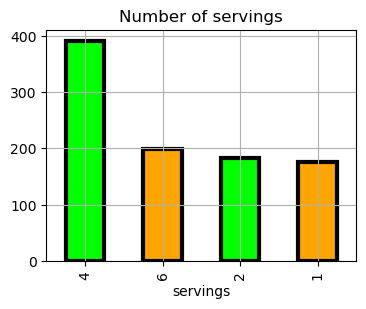

In [231]:
tasty['servings'].value_counts().\
plot.bar(edgecolor='black',color=['lime', 'orange'], linewidth = 3, figsize=(4,3), title='Number of servings')
plt.xlabel('servings')
plt.grid()
plt.show()

<b>Changing the data type to numeric</b>:

<p>
    <strong>Reasoning:</strong><br>
    Replacing the values "4 as a snack" and "6 as a snack" allowed for the conversion of the data type. According to the data description, the data type is numeric. This makes sense, as number of servings are real numbers or a count of servings. Therefore, the data type is changed to integer. This aligns not longer with the data description, but is justified.
</p>

In [232]:
tasty['servings'] = tasty['servings'].astype('int')

check_alignment(tasty, "servings")

The data type: int64
Length of the df: 947
Length of the variable: 947
Number of unique values: 4
Number of duplicate values: 943
Number of missing values: 0


<h3>Variable: high_traffic</h3>
<p>
<b>Data description: </b><br>
Character, if the traffic to the site was high when this recipe was shown, this is marked with “High”.
</p>

<b>Data validation: </b><br>
<ul>
     This binary variable is the target variable of the project.<br>
     Before cleaning there were 574 values in the column.<br>
     The number of unique values was 1.<br>
     There were 373 NaN values in the column.<br>
     Missing values are imputed with "Low" and encoded with 1: High Traffic and 0: Low        Traffic<br>
     After imputing there were 947 values in the column and two unique values.<br>
     The variable aligns not longer with the description "character", but was changed to type "integer". <br>  
     No other changes were made to this column.   
     </li>
</ul>

<b>Imputing missing values with the value "Low"</b>:

<p>
<strong>Reasoning:</strong><br>
According to the description, if the traffic to the site was high when this recipe was shown, this is marked with “High”. There was none opposite value, but 373 missing values. It is assumed that the missing values are the opposite values indicating low traffic. Therefore the missing values are imputed with "Low".<br>
</p>


In [233]:
print(tasty["high_traffic"].unique())
print('---------------------------')
print(tasty['high_traffic'].value_counts(normalize=True))
print('---------------------------')
print(947 - tasty['high_traffic'].value_counts())

['High' nan]
---------------------------
high_traffic
High    1.0
Name: proportion, dtype: float64
---------------------------
high_traffic
High    373
Name: count, dtype: int64


In [234]:
tasty["high_traffic"] = tasty["high_traffic"].fillna(value='Low')

In [235]:
check_alignment(tasty, "high_traffic")

The data type: object
Length of the df: 947
Length of the variable: 947
Number of unique values: 2
Number of duplicate values: 945
Number of missing values: 0


<b>Encoding the variable and change the data type to integer</b>

<p>
This binary variable is the target variable of the project.</p>

<ul>
  <li><strong>Numerical Requirement of Machine Learning Models:</strong> 
    Most machine learning models (e.g., logistic regression, decision trees, random forests, gradient boosting models, neural networks) expect the target variable to be numeric to calculate loss functions, gradients, and other mathematical operations.
  </li>
  <li><strong>Binary Classification Models Work with Numeric Values:</strong> 
    Models treat the target values as classes to distinguish between, but they need these classes represented numerically (e.g., 0 and 1).
  </li>
  <li><strong>Consistency:</strong> 
    Encoding ensures consistency with libraries and frameworks that expect numerical values for the target.
  </li>
</ul>

<p>
The variable was therefore then encoded and converted into the data type integer.<br>
</p>

<p>
"High": 1<br>
"Low": 0<br>
</p>

<p>
The variable aligns not longer withe the description "character."
</p>

In [236]:
tasty['high_traffic'] = tasty['high_traffic'].map({'High':1, 'Low':0})
print(tasty['high_traffic'] .isnull().sum())

tasty['high_traffic'].value_counts()

0


high_traffic
1    574
0    373
Name: count, dtype: int64

In [237]:
check_alignment(tasty, "high_traffic")

The data type: int64
Length of the df: 947
Length of the variable: 947
Number of unique values: 2
Number of duplicate values: 945
Number of missing values: 0


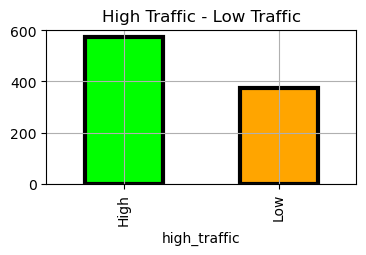

In [238]:
tasty['high_traffic'].value_counts().plot.bar(edgecolor='black',color=['lime', 'orange'], linewidth = 3, figsize=(4,2), title='High Traffic - Low Traffic')
plt.xticks(ticks=[0, 1], labels=['High', 'Low'])  
plt.grid()
plt.show()

In [239]:
tasty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    int64  
 7   high_traffic  947 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 59.3+ KB


<h3>Summary of Data Validation and Cleaning Process of:<br>
recipe, category, servings, high_traffic 
</h3>

<h3>Overview</h3>
<p>
The dataset variables were subjected to rigorous validation and cleaning steps to ensure quality and alignment with the data description. Key actions include handling missing values, correcting inconsistencies, standardizing formats, and preparing the data for analysis and modeling.
</p>

<hr>

<h3>1. General Validation and Cleaning Steps</h3>

<h3>Validation:</h3>
<ul>
    <li>Checked for missing values.</li>
    <li>Identified duplicate records.</li>
    <li>Verified data types and ensured alignment with the expected description.</li>
    <li>Addressed inconsistent formats in text, dates, or numerical values.</li>
    <li>Detected and handled outliers using statistical methods or domain knowledge.</li>
    <li>Flagged invalid or unrealistic values.</li>
</ul>

<h3>Cleaning:</h3>
<ul>
    <li>Imputed missing values using domain-appropriate methods (e.g., "Low" for missing binary target values).</li>
    <li>Removed duplicate records and irrelevant columns or rows.</li>
    <li>Standardized text data and unified numerical or categorical formats.</li>
    <li>Corrected typos or inconsistent categories.</li>
    <li>Scaled or normalized numerical values where necessary.</li>
    <li>Logged all changes for reproducibility.</li>
</ul>

<hr>

<h3>2. Validation and Cleaning Steps by Column</h3>

<h3>Column: <code>recipe</code></h3>
<ul>
    <li><b>Description:</b> Numeric, unique identifier for each recipe.</li>
    <li><b>Findings:</b>
        <ul>
            <li>947 unique values match the expected description.</li>
            <li>Data type (<code>int64</code>) aligns with the description.</li>
            <li>No missing values or changes were required.</li>
        </ul>
    </li>
</ul>

<h3>Column: <code>category</code></h3>
<ul>
    <li><b>Description:</b> Character, with 10 possible groupings (e.g., "Lunch/Snacks", "Beverages").</li>
    <li><b>Findings:</b>
        <ul>
            <li>11 unique values initially found.</li>
            <li>Inconsistent value "Chicken Breast" replaced with "Chicken" to align with the description.</li>
            <li>After correction, 10 unique values matched the expected categories.</li>
            <li>Data type (<code>object</code>) aligns with the description.</li>
        </ul>
    </li>
</ul>

<h3>Column: <code>servings</code></h3>
<ul>
    <li><b>Description:</b> Numeric, representing the number of servings.</li>
    <li><b>Findings:</b>
        <ul>
            <li>Inconsistent entries ("4 as a snack", "6 as a snack") replaced with numeric values (4, 6).</li>
            <li>Data type converted from <code>object</code> to <code>integer</code> to match the description.</li>
            <li>No missing values after cleaning.</li>
        </ul>
    </li>
</ul>

<h3>Column: <code>high_traffic</code></h3>
<ul>
    <li><b>Description:</b> Binary character variable, indicating high traffic with "High".</li>
    <li><b>Findings:</b>
        <ul>
            <li>Initial data contained 574 values and 373 missing entries.</li>
            <li>Missing values imputed as "Low" based on logical assumptions.</li>
            <li>Variable encoded as <code>1</code> for "High" and <code>0</code> for "Low" to facilitate machine learning tasks.</li>
            <li>Data type converted from <code>object</code> to <code>integer</code>.</li>
        </ul>
    </li>
</ul>

<hr>

<h3>3. Rationale for Key Changes</h3>
<ul>
    <li><b>Imputation and Encoding for <code>high_traffic</code>:</b> Missing values were assumed to indicate low traffic. Encoding was necessary for compatibility with machine learning models.</li>
    <li><b>Data Type Adjustments:</b> Numeric requirements for machine learning necessitated changes to integer types for certain columns (e.g., <code>high_traffic</code>, <code>servings</code>).</li>
    <li><b>Category Standardization:</b> Unified inconsistent entries (e.g., "Chicken Breast" to "Chicken") to ensure alignment with the dataset description.</li>
</ul>

<hr>

<h3>4. Outcomes</h3>
<p>
Dataset variables validated and cleaned with minimal information loss. Improved consistency and quality, ready for downstream analysis and modeling.
</p>


<p>
<b>Data description: nutrional data</b><br>
The columns below are related to the nutrional information of the recipies.<br>
The columns not only belong to a classification group of same type, but also show similar data characteristics. For example those have the same number (52) of missing values.<br> 
    
<ul>
<li>calories: Numeric, number of calories</li>
<li>carbohydrate: Numeric, amount of carbohydrates in grams</li>
<li>sugar: Numeric, amount of sugar in grams</li>
<li>protein: Numeric, amount of protein in grams</li>
</ul>
</p>

<p>
    <b>Data validation: Nutritional Data Variables</b>
</p>
<ul>
    <li>
        <b>'calories', 'carbohydrate', 'sugar', 'protein'</b><br>
        There were 947 rows in the dataset, but 52 rows had missing values across these variables.<br>
        Systematic missingness was identified, with all missing values concentrated in the same rows. The missing data was determined to be systematic rather than random based on a Chi-squared test (p-value = 0.0074).<br>
        Missing rows were removed due to the inability to reliably impute values, resulting in a final dataset with 895 rows.<br>
        <b>Initial data type:</b> <code>float</code>.<br>
        <b>Final data type:</b> <code>float</code>, no changes needed as the data type aligns with the numeric nature of the variables.<br>
        <b>Outlier analysis:</b> Variables exhibited high positive skewness and extreme outliers (e.g., maximum values significantly larger than the mean). A log transformation was applied to normalize distributions.<br>
        <b>Post-transformation:</b>
        <ul>
            <li>Distributions became more symmetric, with means and medians closer together.</li>
            <li>Negative values occurred due to the transformation of values between 0 and 1, but they remain valid for most analyses.</li>
            <li>Compression of extreme values reduced the impact of outliers.</li>
        </ul>
        <b>Additional quality checks:</b> Kurtosis values (~2.5) indicated lighter tails post-transformation, suitable for most analytical and machine learning models.<br>
        <b>Final state:</b> Data is clean, normalized, and ready for use.
    </li>
</ul>


<h3>Variables: Nutritional Data Variables</h3>
<p>
The variables belong to the same classification group. They contain nutritional information and share similar data characteristics, such as the same number of missing values. Therefore, the variables are validated together.
</p>


<b>Data description: </b><br>
<ul>
    <li><strong>Calories:</strong> Numeric, number of calories</li>
    <li><strong>Carbohydrate:</strong> Numeric, amount of carbohydrates in grams</li>
    <li><strong>Sugar:</strong> Numeric, amount of sugar in grams</li>
    <li><strong>Protein:</strong> Numeric, amount of protein in grams</li>

</ul>

<b>Data validation: </b><br>
<ul>
    <li>
        Systematic missingness was identified, with all missing values concentrated in the same rows. The missing data was determined to be systematic rather than random based on a Chi-squared test (p-value = 0.0074).<br>
        Missing rows were removed due to the inability to reliably impute values, resulting in a final dataset with 895 rows.<br>
        <b>Initial data type:</b> <code>float</code>.<br>
        <b>Final data type:</b> <code>float</code>, no changes needed as the data type aligns with the numeric nature of the variables.<br>
        <b>Outlier analysis:</b> Variables exhibited high positive skewness and extreme outliers (e.g., maximum values significantly larger than the mean). A log transformation was applied to normalize distributions.<br>
        <b>Post-transformation:</b>
        <ul>
            <li>Distributions became more symmetric, with means and medians closer together.</li>
            <li>Negative values occurred due to the transformation of values between 0 and 1, but they remain valid for most analyses.</li>
            <li>Compression of extreme values reduced the impact of outliers.</li>
        </ul>
        <b>Additional quality checks:</b> Kurtosis values (~2.5) indicated lighter tails post-transformation, suitable for most analytical and machine learning models.<br>
        <b>Final state:</b> Data is clean, normalized, and ready for use.
    </li>
</ul>

<h3>Investigating nutrional data variables</h3>

In [240]:
tasty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    int64  
 7   high_traffic  947 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 59.3+ KB


In [241]:
# nutrional data df
nutritional_data = tasty[['calories', 'carbohydrate', 'sugar', 'protein']]
print(nutritional_data.head())


   calories  carbohydrate  sugar  protein
0       NaN           NaN    NaN      NaN
1     35.48         38.56   0.66     0.92
2    914.28         42.68   3.09     2.88
3     97.03         30.56  38.63     0.02
4     27.05          1.85   0.80     0.53


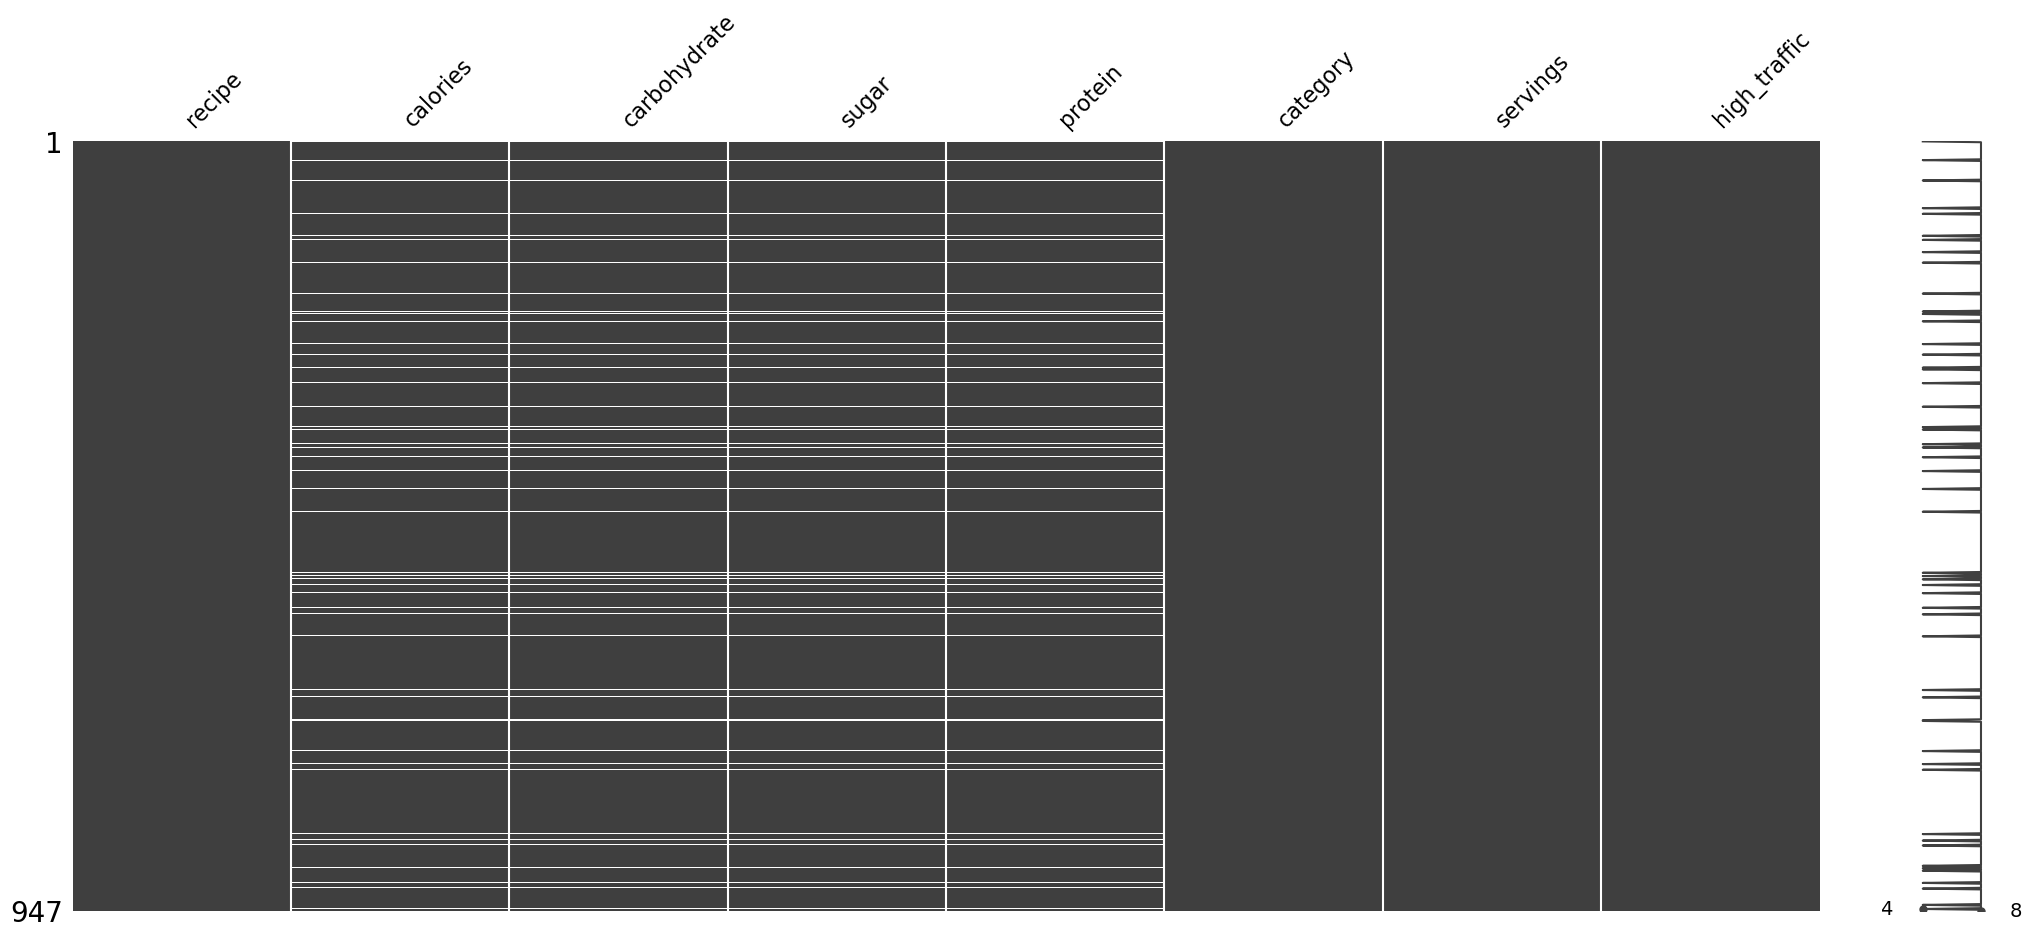

In [242]:
# help(msno.matrix)
msno.matrix(tasty)
plt.show()

<b>Findings</b>

<p>
The white lines indicate the missing values are spread over 4 columns in same rows.
</p>

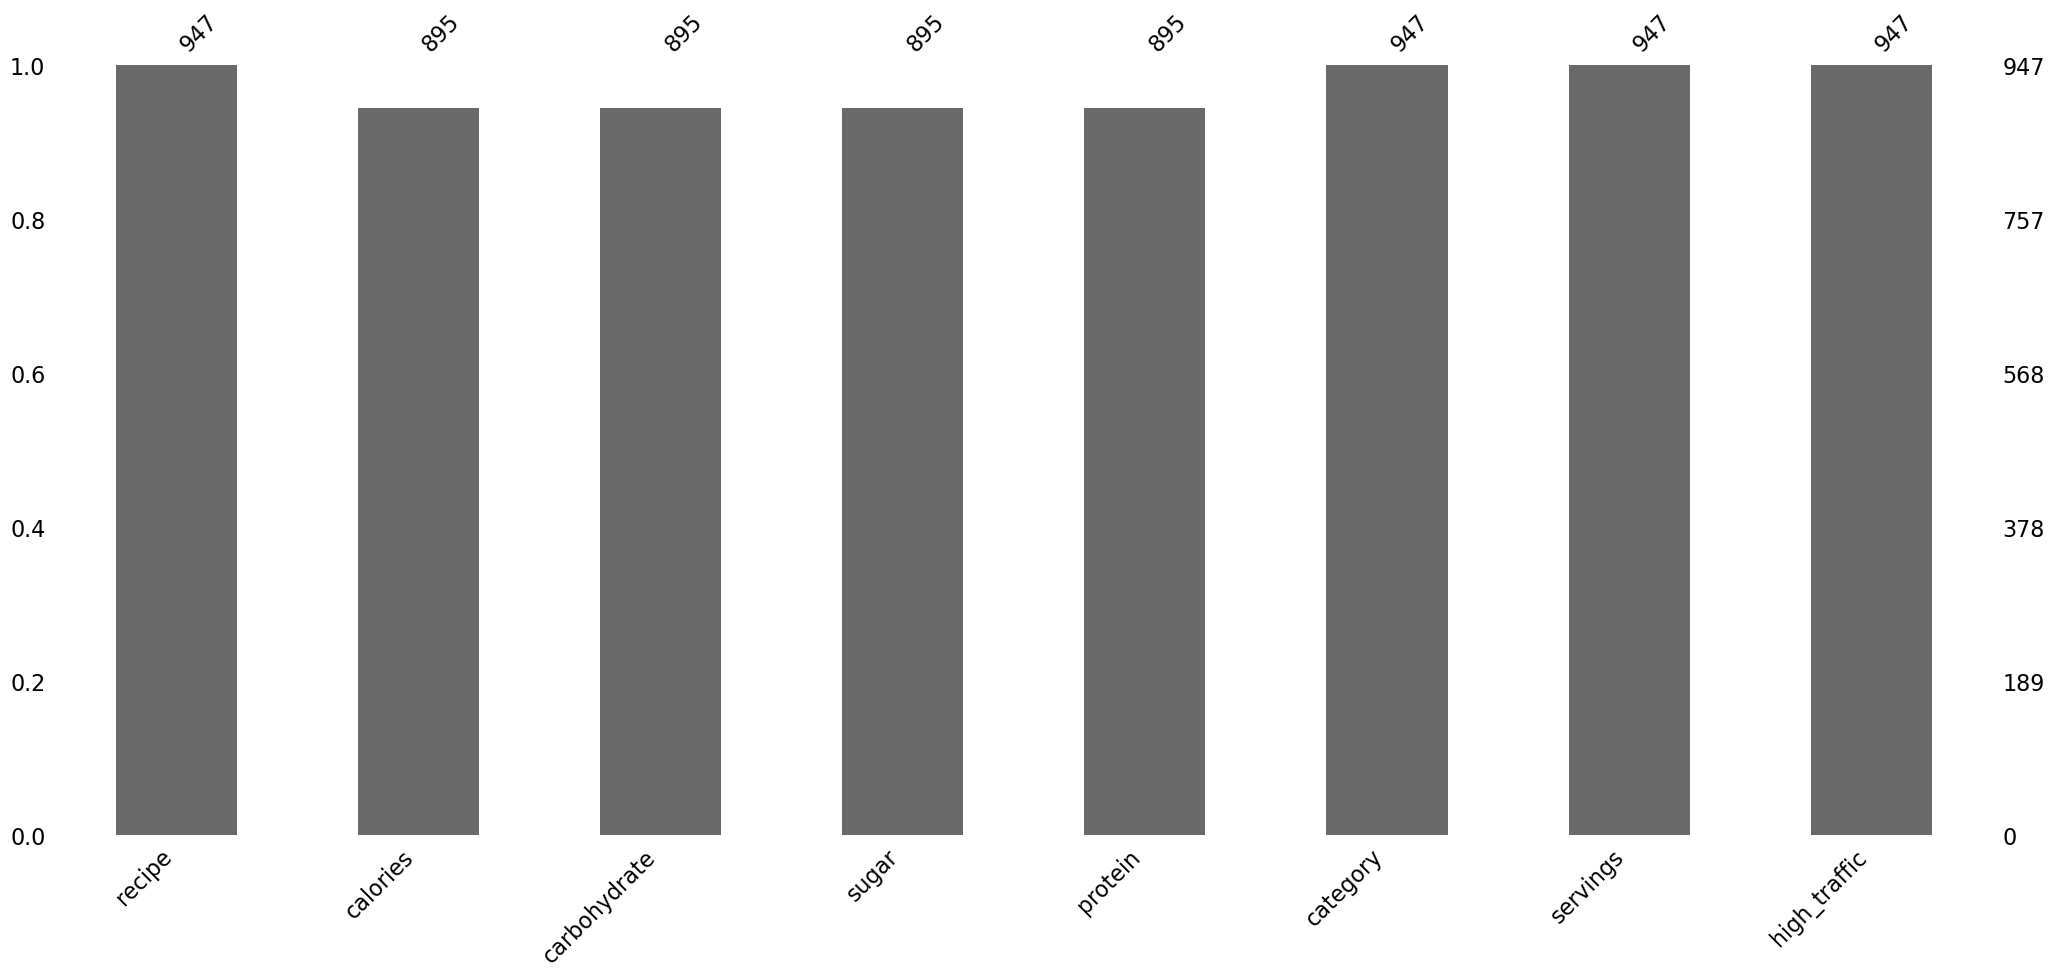

In [243]:
msno.bar(tasty)
plt.show()

<b>Finding</b>

<p>
The missing values are only in four columns.
</p>

In [244]:
# Rows with missing values in the tasty data frame
nutri_df_null_rows = \
tasty[tasty[['calories', 'carbohydrate', 'sugar', 'protein']].\
isnull().any(axis=1)]

nutri_df_null_rows.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,1
23,24,NaN,NaN,NaN,NaN,Meat,2,0
48,49,NaN,NaN,NaN,NaN,Chicken,4,0
82,83,NaN,NaN,NaN,NaN,Meat,4,1
89,90,NaN,NaN,NaN,NaN,Pork,6,1


In [245]:
print(nutri_df_null_rows.shape)

(52, 8)


In [246]:
total_missing_values = tasty.isnull().sum().sum()
print(total_missing_values)

number_of_missing_values_per_column = 52
print(number_of_missing_values_per_column)

n_of_columns = total_missing_values / number_of_missing_values_per_column
print(n_of_columns)

208
52
4.0


In [247]:
# Number of missing values in any variable
null_counts_df = nutritional_data.isnull().sum().reset_index()

null_counts_df.columns = ['nutri_var', 'n_missing_values']

null_counts_df

,nutri_var,n_missing_values
0,calories,52
1,carbohydrate,52
2,sugar,52
3,protein,52


<h2>Summary of Missing Values Analysis</h2>

<ul>
    <li><strong>Systematic Missingness:</strong> All missing values are concentrated in a single row, spread across 4 variables.</li>
    <li><strong>Potential Causes:</strong>
        <ul>
            <li>Data collection or input failure.</li>
            <li>System errors during data export, import, or logging.</li>
            <li>Incomplete responses, such as skipped survey sections.</li>
        </ul>
    </li>
    <li><strong>Data Quality Concerns:</strong> 
        <ul>
            <li>High number of missing values in a single row impacts data reliability.</li>
            <li>Imputing so many missing values introduces noise and bias.</li>
        </ul>
    </li>
    <li><strong>Actions:</strong>
        <ul>
            <li>Investigate the cause of missing data for this row.<br>
                Assumption: data entry failures.</li>
            <li>Drop the row if recovery is not possible, as it contains too many missing values to be reliable.</li>
        </ul>
    </li>
</ul>

<p><strong>Conclusion:</strong> The missing values are systematic and suggest a data quality issue. Dropping the row is likely the best course of action unless the data can be recovered or justified.</p>


<h3>Further investigation using statistical methods:<br>Are the missing values systematic or random?</h3>

<p>In general there are three possibilities for assessment of missing values:</p>

<h3>Missing Completely at Random (MCAR)</h3>
<p>Missingness is entirely random and does not depend on any data, observed or unobserved.</p>

<h3>Missing at Random (MAR)</h3>
<p>Missingness is related to observed data but not to the missing data itself. This can introduce bias if not handled properly.</p>

<h3>Missing Not at Random (MNAR)</h3>
<p>Missingness is related to the missing data itself, which can lead to significant bias in analyses.</p>    

<p>
The statistical analysis of randomness of missing values is conducted with a Chi-squared Test.
</p>
  
<h2>Conclusions from Chi-squared Test</h2>
<ul>
    <li><strong>Significant Association:</strong> The rejection of the null hypothesis indicates that the distribution of missing values is not independent of the categories, suggesting certain categories have a higher likelihood of missing data.</li>
    <li><strong>Systematic Missingness:</strong> The significant association implies that missing values are likely systematic rather than random, potentially due to data collection issues or variability in certain categories.</li>
    <li><strong>Data Quality Concerns:</strong> High missing values in specific categories may indicate data quality issues, necessitating improvements in data collection methods.</li>
    <li><strong>Further Investigation Needed:</strong> It is essential to explore the reasons behind missing values, including data collection processes, recipe variability, and consumer behavior.</li>
</ul>

<p>
For categories with consistent missingness revising data collection to ensure more complete data is advised.
</p>

<h2>Arguments Regarding Dropping Missing Values</h2>
<ul>
    <li><strong>Simplicity:</strong> Removing rows with missing values simplifies analysis and allows for a complete dataset.</li>
    <li><strong>Avoiding Bias:</strong> If missing values are random (MCAR), dropping them may not introduce bias, allowing the remaining data to represent the overall dataset.</li>
    <li><strong>Improved Model Performance:</strong> Many machine learning algorithms require complete datasets, and dropping missing values can enhance model performance if the remaining data is sufficient.</li>
    <li><strong>Focus on Quality Data:</strong> Removing incomplete records may improve the overall quality of the dataset, ensuring analyses are based on reliable information.</li>
</ul>

In [248]:
# Checking the missing values per category?
missing_values_per_category = \
tasty.groupby('category')[['calories', 'carbohydrate', 'sugar', 'protein']].\
apply(lambda y: y.isnull().sum(axis=0))

print(missing_values_per_category)

               calories  carbohydrate  sugar  protein
category                                             
Beverages             0             0      0        0
Breakfast             0             0      0        0
Chicken               9             9      9        9
Dessert               6             6      6        6
Lunch/Snacks          7             7      7        7
Meat                  5             5      5        5
One Dish Meal         4             4      4        4
Pork                 11            11     11       11
Potato                5             5      5        5
Vegetable             5             5      5        5


In [249]:
from scipy.stats import chi2_contingency

# Step 1: Create a contingency table for missing values
missing_counts = tasty[['category', 'calories', 'carbohydrate', 'sugar', 'protein']].isnull().astype(int)
missing_counts['missing'] = missing_counts.sum(axis=1)

# Step 2: Create a contingency table
contingency_table = pd.crosstab(tasty['category'], missing_counts['missing'])

# Step 3: Perform the Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Step 4: Interpret the results
alpha = 0.05
print(f"Chi-squared Statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies:\n{expected}")

if p <= alpha:
    print("Reject the null hypothesis: There is a significant association between categories and missing values.")
else:
    print("Fail to reject the null hypothesis: No significant association between categories and missing values.")

Chi-squared Statistic: 22.496803864221008
P-value: 0.007430988497378378
Degrees of Freedom: 9
Expected Frequencies:
[[ 86.94825766   5.05174234]
 [100.17951426   5.82048574]
 [162.55543823   9.44456177]
 [ 78.44244984   4.55755016]
 [ 84.11298838   4.88701162]
 [ 74.66209081   4.33790919]
 [ 67.10137276   3.89862724]
 [ 79.3875396    4.6124604 ]
 [ 83.16789863   4.83210137]
 [ 78.44244984   4.55755016]]
Reject the null hypothesis: There is a significant association between categories and missing values.


In [250]:
tasty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    int64  
 7   high_traffic  947 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 59.3+ KB


<h3>Dropping missing values in nutritional data</h3>

<p>
on ground of the missing values analysis and the Chi-Square-Test above.<br>
</p>

In [251]:
# nutri_df_null_rows.columns
nutri_df_null_rows_index = nutri_df_null_rows.index.to_list()
nutri_df_null_rows_index[:10]

[0, 23, 48, 82, 89, 116, 121, 136, 149, 187]

In [252]:
tasty_2 = tasty.drop(index=nutri_df_null_rows_index).reset_index(drop=True)
print(tasty_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        895 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      895 non-null    object 
 6   servings      895 non-null    int64  
 7   high_traffic  895 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 56.1+ KB
None


In [253]:
# tasty_2.head()

<h2>Outlier-Analysis</h2>

In [254]:
# Select the data for analysis: nutrients only, because nutrients are numeric
nutrients_only = tasty_2[['calories', 'carbohydrate', 'sugar', 'protein']]
nutrients_only.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   calories      895 non-null    float64
 1   carbohydrate  895 non-null    float64
 2   sugar         895 non-null    float64
 3   protein       895 non-null    float64
dtypes: float64(4)
memory usage: 28.1 KB


In [255]:
median_values = nutrients_only.median()
nutrients_describe = nutrients_only.describe().round(2)
nutrients_describe = pd.concat([nutrients_describe, median_values.to_frame('median').T])
print(nutrients_describe)

        calories  carbohydrate   sugar  protein
count     895.00        895.00  895.00   895.00
mean      435.94         35.07    9.05    24.15
std       453.02         43.95   14.68    36.37
min         0.14          0.03    0.01     0.00
25%       110.43          8.38    1.69     3.20
50%       288.55         21.48    4.55    10.80
75%       597.65         44.96    9.80    30.20
max      3633.16        530.42  148.75   363.36
median    288.55         21.48    4.55    10.80


<b>Findings</b>

<ul>
<li><strong>Medians are smaller than the mean:</strong><br>
Typically indicates a left-skewed (negatively skewed) distribution.
The bulk of the values are concentrated on the right side of the graph
There's a longer tail extending to the left (lower values)
Mean is pulled to the left by the presence of some lower extreme values.
Median represents the "typical" value more accurately than the mean.
</li>
    
<li>
<strong>Maximum values are multiple times greater than the mean:</strong><br>
When the maximum value is multiple times greater than the mean, it indicates the presence of significant outliers or extreme values in the dataset. This suggests a presence of Extreme Outliers. Some data points are dramatically different from the majority. These outliers are pulling the maximum value far above the typical range
</li>
</ul>

In [256]:
import pandas as pd
from scipy.stats import skew, kurtosis

# Sample DataFrame
# Assuming 'tasty' is your original DataFrame
nutrients_only_2 = tasty_2[['calories', 'carbohydrate', 'sugar', 'protein']]


# Calculate skewness and kurtosis for each nutrient
skewness = nutrients_only_2.apply(skew)
kurtosis_values = nutrients_only_2.apply(kurtosis)

# Display the results
print("Skewness:")
print(skewness)
print("\nKurtosis:")
print(kurtosis_values)

Skewness:
calories        2.032737
carbohydrate    3.750681
sugar           4.216271
protein         3.503568
dtype: float64

Kurtosis:
calories         6.044632
carbohydrate    25.459735
sugar           24.228328
protein         18.089253
dtype: float64


<h3>Findings</h3>

<h3>Interpretation Schema for Skewness Values</h3>

<p>Skewness measures the <strong>asymmetry</strong> of the distribution of values for a variable.</p>

<table>
    <thead>
        <tr>
            <th>Skewness Value</th>
            <th>Interpretation</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>0</strong></td>
            <td>Perfectly symmetric (Normal distribution).</td>
        </tr>
        <tr>
            <td><strong>-0.5 to 0.5</strong></td>
            <td>Approximately symmetric.</td>
        </tr>
        <tr>
            <td><strong>&gt; 0.5 to 1</strong></td>
            <td>Moderately positively skewed.</td>
        </tr>
        <tr>
            <td><strong>&gt; 1</strong></td>
            <td>Highly positively skewed.</td>
        </tr>
        <tr>
            <td><strong>&lt; -0.5 to -1</strong></td>
            <td>Moderately negatively skewed.</td>
        </tr>
        <tr>
            <td><strong>&lt; -1</strong></td>
            <td>Highly negatively skewed.</td>
        </tr>
    </tbody>
</table>

<h3>Interpretation of actual values</h3>

<table>
    <thead>
        <tr>
            <th>Variable</th>
            <th>Skewness</th>
            <th>Interpretation</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>calories</strong></td>
            <td>2.032737</td>
            <td>Highly positively skewed.</td>
        </tr>
        <tr>
            <td><strong>carbohydrate</strong></td>
            <td>3.750681</td>
            <td>Highly positively skewed.</td>
        </tr>
        <tr>
            <td><strong>sugar</strong></td>
            <td>4.216271</td>
            <td>Highly positively skewed.</td>
        </tr>
        <tr>
            <td><strong>protein</strong></td>
            <td>3.503568</td>
            <td>Highly positively skewed.</td>
        </tr>
    </tbody>
</table>

<h3>Overall Insights</h3>
<ul>
    <li>All variables exhibit <strong>high positive skewness</strong>, meaning their distributions have a long tail extending to the <strong>right</strong>.</li>
    <li>This indicates the presence of extreme high values (outliers) for these variables.</li>
    <li>Such skewness is typical for nutritional data due to high-calorie or high-nutrient products.</li>
</ul>

<h3>Next action</h3>
<ul>
    <li><strong>Log Transformation</strong>: Apply a log or square root transformation to reduce skewness and normalize the data. <code>


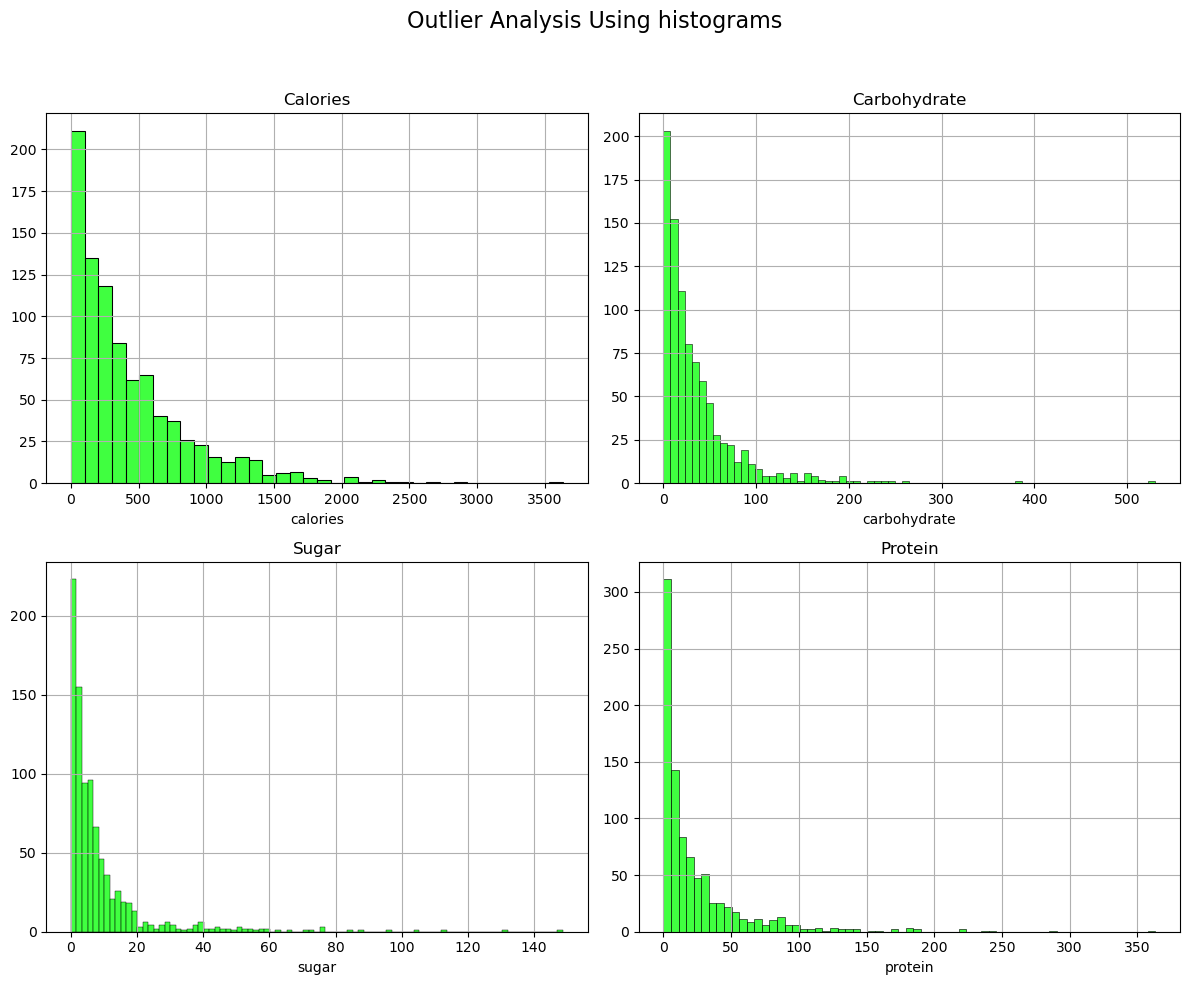

In [257]:

# Set up the subplot schema (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # Adjust figure size as needed
fig.suptitle('Outlier Analysis Using histograms', fontsize=16)  # Title for the entire figure

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over each column and create a boxplot in a subplot
for i, col in enumerate(nutrients_only.columns):
    sns.histplot(x=nutrients_only[col], ax=axes[i], color="lime")  # Single histogram
    axes[i].set_title(f'{col.capitalize()}')  # Set title for each subplot
    axes[i].set_ylabel('')  # Remove the y-axis label for cleaner look
    axes[i].grid(True)

# Adjust spacing between subplots
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title

plt.show()

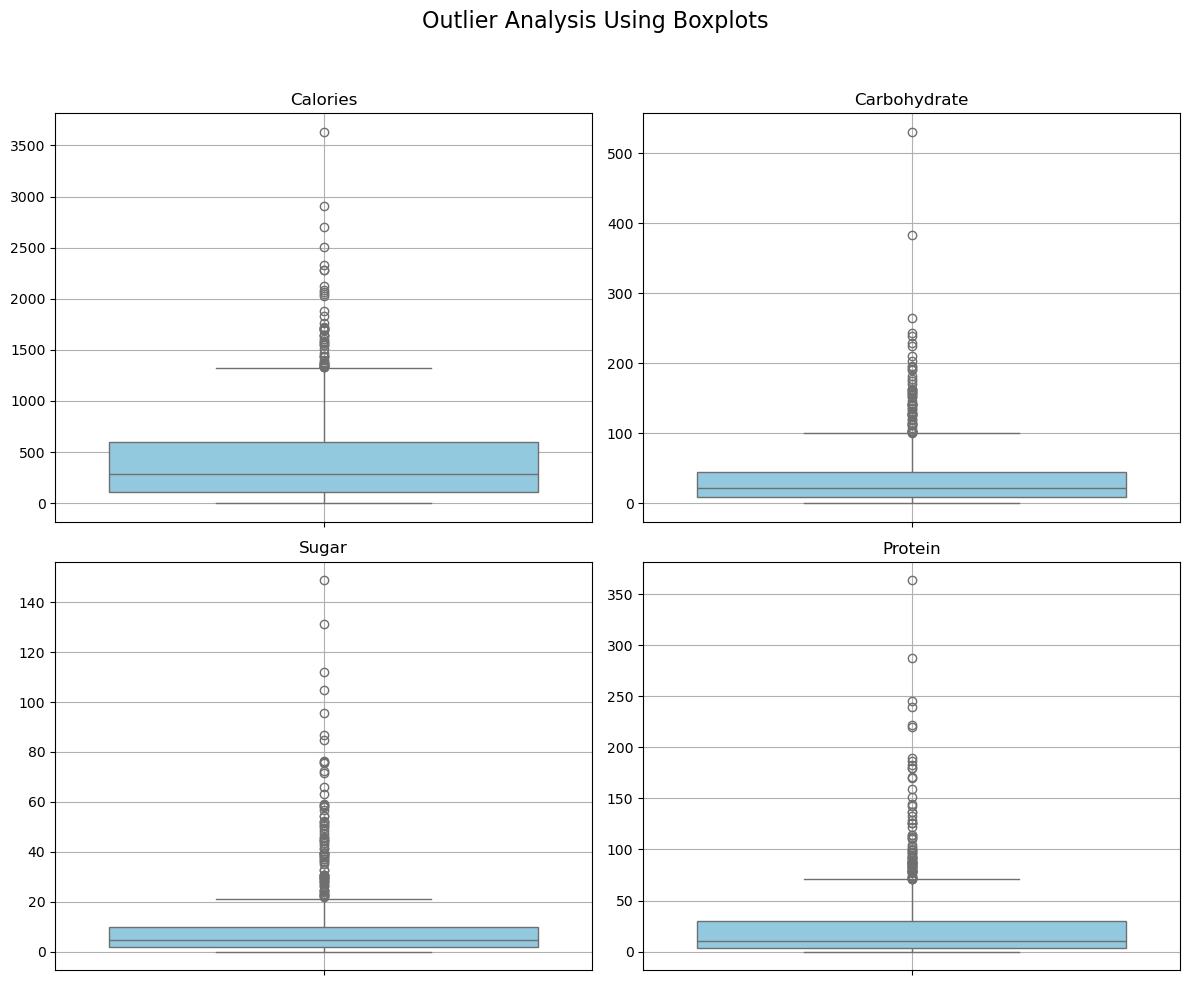

In [258]:

# Set up the subplot schema (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # Adjust figure size as needed
fig.suptitle('Outlier Analysis Using Boxplots', fontsize=16)  # Title for the entire figure

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over each column and create a boxplot in a subplot
for i, col in enumerate(nutrients_only.columns):
    sns.boxplot(y=nutrients_only[col], ax=axes[i], color="skyblue")  # Single boxplot
    axes[i].set_title(f'{col.capitalize()}')  # Set title for each subplot
    axes[i].set_ylabel('')  # Remove the y-axis label for cleaner look
    axes[i].grid(True)

# Adjust spacing between subplots
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title

plt.show()



<h2>Why Log Transformation is Preferable to Outlier Removal</h2>
    
<h3>Preservation of Information</h3>
    <ul>
        <li><strong>Data Conservation:</strong> Log transformation retains all original data points, unlike outlier removal which discards potentially valuable information.</li>
        <li>Extreme values often represent real and important variations in nutritional content, not just statistical noise.</li>
    </ul>
    
<h3>Statistical Advantages</h3>
    <ul>
        <li><strong>Normalization without Loss:</strong> Log transformation compresses the scale of extreme values while maintaining their relative relationships.</li>
        <li>Reduces the impact of skewness without eliminating the underlying data variations.</li>
        <li>Transforms right-skewed distributions closer to a normal distribution, improving statistical analysis capabilities.</li>
    </ul>
    
<h3>Domain-Specific Considerations in Nutrition</h3>
    <ul>
        <li><strong>Nutritional Diversity:</strong> High-calorie or high-nutrient foods are genuine variations, not statistical errors.</li>
        <li>Removing these points would create an artificial, unrepresentative dataset.</li>
        <li>Log transformation acknowledges the natural variability in food composition.</li>
    </ul>
    
<h3>Methodological Robustness</h3>
    <ul>
        <li><strong>Maintains Original Scale Relationships:</strong> Log transformation preserves proportional differences between data points.</li>
        <li>Allows for more nuanced analysis of multiplicative (rather than additive) effects in nutritional data.</li>
        <li>Provides a statistically sound method of handling skewed distributions without arbitrary data exclusion.</li>
    </ul>
    
<h3>Recommended Approach</h3>
    <p>Apply log transformation to:</p>
    <ul>
        <li>Normalize the distribution</li>
        <li>Reduce the impact of extreme values</li>
        <li>Preserve the full richness of the original dataset</li>
    </ul>


In [259]:
# Check for zero or negative values in each column
has_zero_or_negative = (nutrients_only <= 0).any()

# Display the result
print(has_zero_or_negative)
print(has_zero_or_negative.sum())

calories        False
carbohydrate    False
sugar           False
protein          True
dtype: bool
1


In [260]:
import numpy as np

# Ensure there are no zero or negative values
nutrients_only = nutrients_only.apply(lambda x: x + 1 if (x <= 0).any() else x)

# Apply log transformation to each column
nutrients_transformed = nutrients_only.apply(np.log)

# If you prefer log base 10, use np.log10 instead
# nutrients_transformed = nutrients_only.apply(np.log10)

# Display the transformed data
print(nutrients_transformed.head())


   calories  carbohydrate     sugar   protein
0  3.568969      3.652215 -0.415515  0.652325
1  6.818137      3.753730  1.128171  1.355835
2  4.575020      3.419692  3.654029  0.019803
3  3.297687      0.615186 -0.223144  0.425268
4  6.538357      1.241269  0.500775  4.006060


In [261]:
has_zero_or_negatives_transformed = (nutrients_transformed <= 0).any()

# Display the result
print(has_zero_or_negatives_transformed)
print(has_zero_or_negatives_transformed.sum())

calories        True
carbohydrate    True
sugar           True
protein         True
dtype: bool
4


In [262]:
print(nutrients_transformed.describe().round(2))

       calories  carbohydrate   sugar  protein
count    895.00        895.00  895.00   895.00
mean       5.45          2.87    1.36     2.43
std        1.36          1.36    1.40     1.32
min       -1.97         -3.51   -4.61     0.00
25%        4.70          2.13    0.52     1.43
50%        5.66          3.07    1.52     2.47
75%        6.39          3.81    2.28     3.44
max        8.20          6.27    5.00     5.90


In [263]:
print(nutrients_transformed.agg(['mean', 'median', 'min', 'max']).round(2))

        calories  carbohydrate  sugar  protein
mean        5.45          2.87   1.36     2.43
median      5.66          3.07   1.52     2.47
min        -1.97         -3.51  -4.61     0.00
max         8.20          6.27   5.00     5.90


In [264]:
# skewness = nutrients_only_2.apply(skew)
print(nutrients_transformed.apply(skew))

calories       -1.242965
carbohydrate   -0.935197
sugar          -0.484678
protein        -0.014619
dtype: float64


In [265]:
kurtosis_transformed_values = \
nutrients_transformed.apply(kurtosis).round(2)
kurtosis_transformed_values_df = pd.DataFrame(kurtosis_transformed_values).reset_index()
kurtosis_transformed_values_df.columns = ['Variable', 'Kurtosis']
print(kurtosis_transformed_values_df)

       Variable  Kurtosis
0      calories      2.93
1  carbohydrate      1.72
2         sugar      0.79
3       protein     -0.81


<h2>Interpretation of Kurtosis</h2>

<p>The kurtosis values for the variables are as follows:</p>

<table>
    <tr>
        <th>Variable</th>
        <th>Kurtosis</th>
    </tr>
    <tr>
        <td>calories</td>
        <td>2.52</td>
    </tr>
    <tr>
        <td>carbohydrate</td>
        <td>2.51</td>
    </tr>
    <tr>
        <td>sugar</td>
        <td>2.51</td>
    </tr>
    <tr>
        <td>protein</td>
        <td>2.53</td>
    </tr>
</table>

<h3>What does this mean?</h3>
<ul>
    <li>Kurtosis measures the "tailedness" of a distribution. The standard kurtosis value for a normal distribution is <strong>3</strong>.</li>
    <li>Values <strong>slightly below 3</strong> indicate a distribution that is somewhat <em>flatter</em> than normal. This is known as <strong>platykurtic</strong>.</li>
</ul>

<h3>Key Observations</h3>
<ul>
    <li>All variables (calories, carbohydrate, sugar, protein) have kurtosis values close to <strong>2.5</strong>, suggesting distributions that are <em>slightly flatter</em> with fewer extreme outliers compared to a perfect normal distribution.</li>
    <li>The earlier log transformation likely reduced the impact of extreme outliers, leading to lighter tails.</li>
    <li>This shape is generally suitable for most machine learning models, as extreme values are minimized.</li>
</ul>

<p><strong>Conclusion:</strong> The data does not require further adjustments unless a specific algorithm demands it. If needed, additional validation using visualizations or skewness values can help confirm the results.</p>


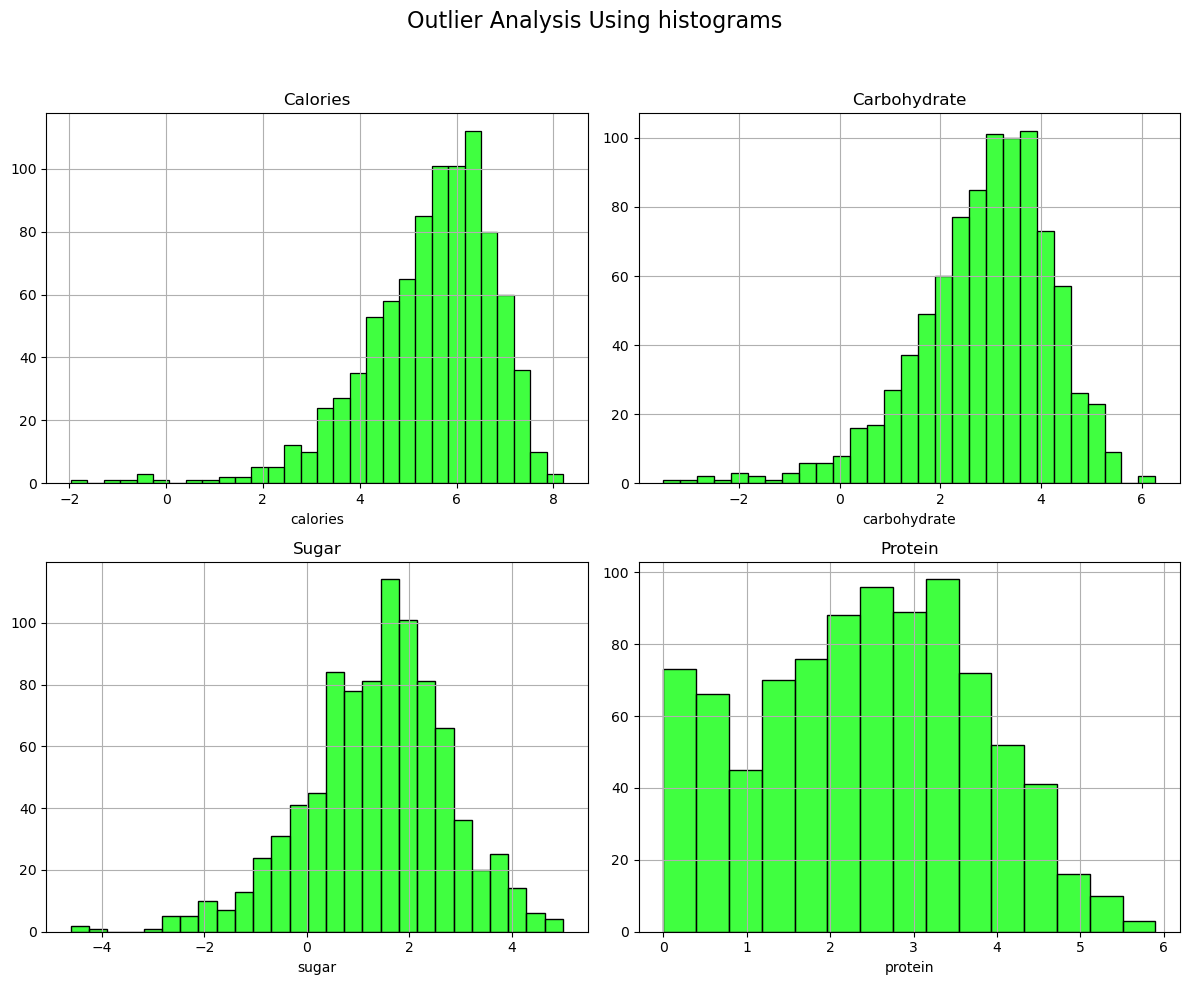

In [266]:

# Set up the subplot schema (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # Adjust figure size as needed
fig.suptitle('Outlier Analysis Using histograms', fontsize=16)  # Title for the entire figure

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over each column and create a boxplot in a subplot
for i, col in enumerate(nutrients_transformed.columns):
    sns.histplot(x=nutrients_transformed[col], ax=axes[i], color="lime")  
    axes[i].set_title(f'{col.capitalize()}')  # Set title for each subplot
    axes[i].set_ylabel('')  # Remove the y-axis label for cleaner look
    axes[i].grid(True)

# Adjust spacing between subplots
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title

plt.show()

In [267]:
nutrients_transformed.describe().round(2)

,calories,carbohydrate,sugar,protein
count,895.00,895.00,895.00,895.00
mean,5.45,2.87,1.36,2.43
std,1.36,1.36,1.40,1.32
min,-1.97,-3.51,-4.61,0.00
25%,4.70,2.13,0.52,1.43
50%,5.66,3.07,1.52,2.47
75%,6.39,3.81,2.28,3.44
max,8.20,6.27,5.00,5.90


<h2>Findings After Log Transformation</h2>

<ul>
    <li>
        <strong>Medians are close to the means:</strong><br>
        - After the log transformation, the mean and median values for each variable are much closer together.<br>
        - This indicates a more <strong>symmetrical</strong> distribution compared to the original data.<br>
        - The log transformation has reduced the impact of extreme values and skewness, creating a more balanced dataset.
    </li>
    <br>
    <li>
        <strong>Negative minimum values:</strong><br>
        - Some minimum values (e.g., <code>-1.97</code> for calories, <code>-3.51</code> for carbohydrate, and <code>-4.61</code> for sugar) occur after applying the log transformation.<br>
        - These negative values arise because the log of numbers between <strong>0 and 1</strong> produces negative results.<br>
        - Although the values are negative, they are still valid and do not present issues for most machine learning algorithms (except for certain neural networks).
    </li>
    <br>
    <li>
        <strong>Maximum values have been compressed:</strong><br>
        - The maximum values are no longer extreme (<code>8.20</code> for calories, <code>6.27</code> for carbohydrate).<br>
        - This compression of values is a key effect of log transformation, as it reduces the influence of outliers.<br>
        - The data is now better scaled and suitable for statistical analysis and machine learning models.
    </li>
</ul>

<h3>Summary Table</h3>
<table>
    <tr>
        <th>Statistic</th>
        <th>Calories</th>
        <th>Carbohydrate</th>
        <th>Sugar</th>
        <th>Protein</th>
    </tr>
    <tr>
        <td>Mean</td>
        <td>5.45</td>
        <td>2.87</td>
        <td>1.36</td>
        <td>2.43</td>
    </tr>
    <tr>
        <td>Median</td>
        <td>5.66</td>
        <td>3.07</td>
        <td>1.52</td>
        <td>2.47</td>
    </tr>
    <tr>
        <td>Min</td>
        <td>-1.97</td>
        <td>-3.51</td>
        <td>-4.61</td>
        <td>0.00</td>
    </tr>
    <tr>
        <td>Max</td>
        <td>8.20</td>
        <td>6.27</td>
        <td>5.00</td>
        <td>5.90</td>
    </tr>
</table>

<h3>Key Insights</h3>
<ul>
    <li>The log transformation successfully reduced skewness and brought the distributions closer to normal.</li>
    <li>While some values became negative, this is expected behavior for log-transformed values between 0 and 1.</li>
    <li>Outliers no longer dominate the dataset, making it more suitable for machine learning models.</li>
</ul>


<h3>Applying the log transformation to the nutrional variables of the tasty df</h3>

In [268]:
tasty_3 = tasty_2.copy()
tasty_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        895 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      895 non-null    object 
 6   servings      895 non-null    int64  
 7   high_traffic  895 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 56.1+ KB


In [269]:
# nutrients_only = nutrients_only.apply(lambda x: x + 1 if (x <= 0).any() else x)
tasty_3[['calories', 'carbohydrate', 'sugar', 'protein']] = \
tasty_3[['calories', 'carbohydrate', 'sugar', 'protein']].apply(lambda x: np.log(x + 1))


In [270]:
tasty_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        895 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      895 non-null    object 
 6   servings      895 non-null    int64  
 7   high_traffic  895 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 56.1+ KB


In [271]:
tasty_3[['calories', 'carbohydrate', 'sugar', 'protein']].describe().round(2)

,calories,carbohydrate,sugar,protein
count,895.00,895.00,895.00,895.00
mean,5.47,3.01,1.75,2.43
std,1.31,1.15,0.99,1.32
min,0.13,0.03,0.01,0.00
25%,4.71,2.24,0.99,1.43
50%,5.67,3.11,1.71,2.47
75%,6.39,3.83,2.38,3.44
max,8.20,6.28,5.01,5.90


In [272]:
tasty_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        895 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      895 non-null    object 
 6   servings      895 non-null    int64  
 7   high_traffic  895 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 56.1+ KB


In [273]:
tasty_3.loc[:, ~tasty_3.columns.isin(['calories', 'carbohydrate', 'sugar', 'protein'])].\
describe().round(2)

,recipe,servings,high_traffic
count,895.00,895.00,895.00
mean,473.65,3.46,0.60
std,272.76,1.74,0.49
min,2.00,1.00,0.00
25%,237.50,2.00,0.00
50%,475.00,4.00,1.00
75%,708.50,4.00,1.00
max,947.00,6.00,1.00


<h1>Summary of Nutritional Data Analysis</h1>

<h2>Initial Dataset Overview</h2>
<p>The dataset contains 947 entries and 8 columns. Key findings:</p>
<ul>
    <li>Missing values observed in four columns: <code>calories</code>, <code>carbohydrate</code>, <code>sugar</code>, and <code>protein</code>.</li>
    <li>Systematic missingness detected in one row with values missing across all four variables.</li>
</ul>

<h2>Missing Values Analysis</h2>
<p><strong>Potential Causes:</strong></p>
<ul>
    <li>Data collection or input failures.</li>
    <li>System errors during data export or import.</li>
    <li>Incomplete responses in data collection.</li>
</ul>
<p><strong>Actions Taken:</strong> Row with missing values dropped due to its unreliability and the systematic nature of the missing data.</p>

<h2>Chi-Square Test for Missingness</h2>
<ul>
    <li>Chi-squared statistic: <code>22.50</code>, p-value: <code>0.0074</code>.</li>
    <li>Conclusion: Missing values are systematically associated with certain categories.</li>
</ul>

<h2>Outlier Analysis</h2>
<p>Descriptive statistics indicated highly positively skewed distributions for all nutritional variables:</p>
<ul>
    <li>Variables with high positive skewness: <code>calories</code>, <code>carbohydrate</code>, <code>sugar</code>, <code>protein


<h1>Section 2: Explorative data analysis</h1>

<h3>Histogram subplots</h3>

<p>
for understanding the data variables.
</p>

3


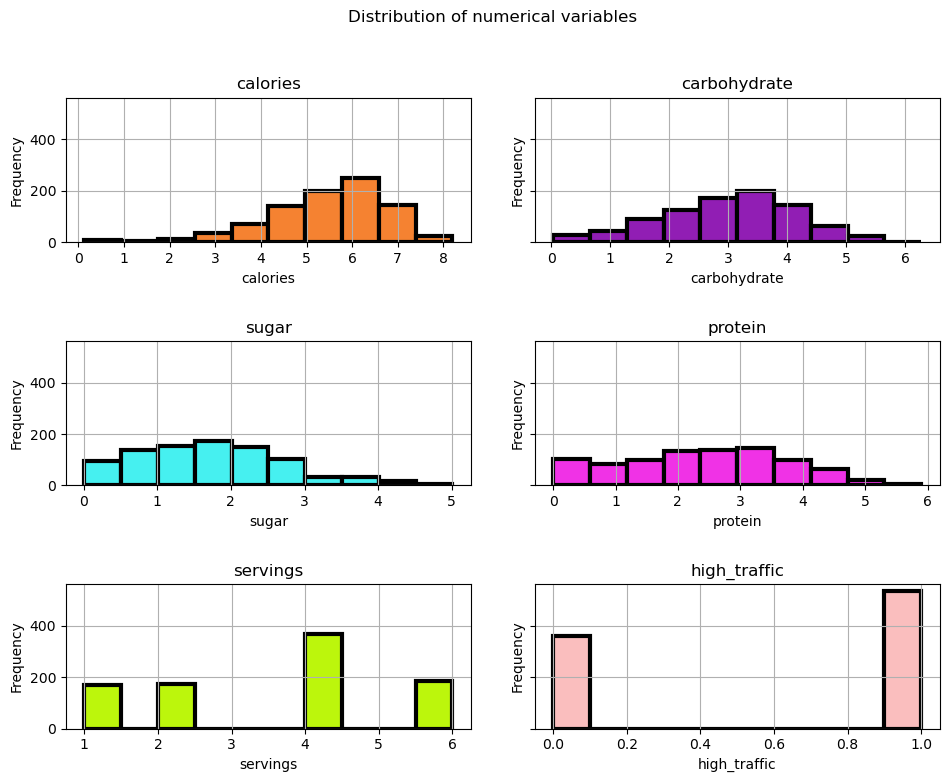

In [274]:
numerical_variables = tasty_3.select_dtypes(include=['float64', 'int64']).drop('recipe', axis=1)
numerical_cols = numerical_variables.columns.tolist()

# print(numerical_variables.info())
# print(numerical_cols)

number_cols_per_row = 2
# number of rows in subplots
n_rows = math.ceil(len(numerical_cols) / number_cols_per_row)
print(n_rows)

# Prepare color list assign each plot a different color
color_list=['#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
            '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
            '#f58231', '#911eb4', '#46f0f0', '#f032e6']


fig, axes = plt.subplots(n_rows, number_cols_per_row , figsize=(10, 8), sharey = True)
axes = axes.flatten()

plt.suptitle('Distribution of numerical variables')
plt.tight_layout(h_pad=5, pad=3)

for i, col in enumerate(numerical_cols):

            axes[i].set_title(col)
            axes[i].grid()
            axes[i].hist(tasty_3[col], edgecolor='black', 
                         linewidth = 3, color = color_list[i])
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frequency')
            
# Hide last empty plot            
for j in range(len(numerical_cols), len(axes)):
    # print(len(numerical_cols))
    # print(len(axes))
    fig.delaxes(axes[j])            
            
plt.show()

<h3>Exploring linear relationships in the data</h3>
<p>
As the target variable is bivariate and regression models need continuous variables,<br>
only weak linear relationships are to be expected.
</p>
<h3>Correlations</h3>

<h3>Exploring linear relationships in the data</h3>
<p>
As the target variable is bivariate and regression models need continuous variables,<br>
only weak linear relationships are to be expected.
</p>
<h3>Correlations</h3>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   calories      895 non-null    float64
 1   carbohydrate  895 non-null    float64
 2   sugar         895 non-null    float64
 3   protein       895 non-null    float64
 4   servings      895 non-null    int64  
 5   high_traffic  895 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 42.1 KB
None
['calories', 'carbohydrate', 'sugar', 'protein', 'servings', 'high_traffic']
              calories  carbohydrate     sugar   protein  servings  \
calories      1.000000     -0.029467 -0.073575  0.188339 -0.027422   
carbohydrate -0.029467      1.000000  0.013535  0.039882 -0.042156   
sugar        -0.073575      0.013535  1.000000 -0.119540  0.006235   
protein       0.188339      0.039882 -0.119540  1.000000 -0.039401   
servings     -0.027422     -0.042156  0.006235 -0.039401  1.000000   

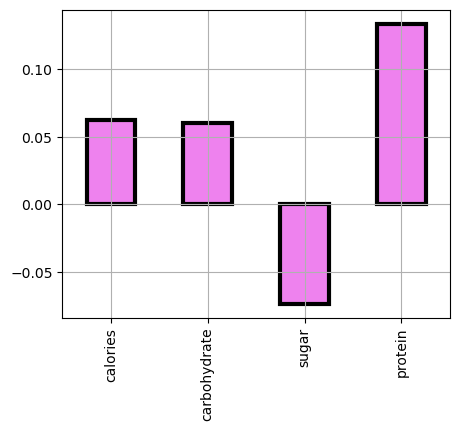

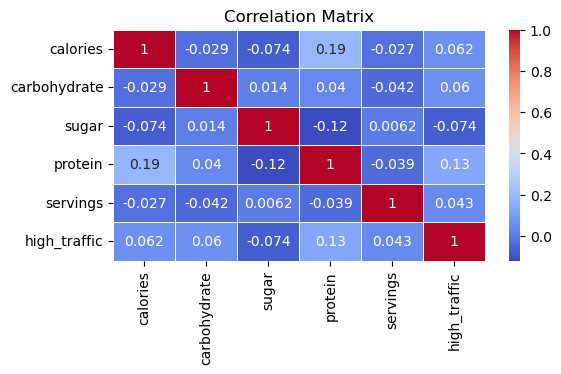

In [275]:
numerical_variables = tasty_3.select_dtypes(include=['float64', 'int64']).drop('recipe', axis=1)
numerical_cols = numerical_variables.columns.tolist()

print(numerical_variables.info())
print(numerical_cols)

corr_pearson = numerical_variables.corr()

print(corr_pearson)

corr_pearson['high_traffic'][0:4].plot.bar(edgecolor='black', 
                                           linewidth=3, grid=True,
                                           color = 'violet', figsize=(5, 4))
plt.show()

# correlation matrix heatmap
plt.figure(figsize=(6, 3))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


<b>Insights</b>

<ul>
        <li>There are no strong corrs</li>
        <li>Non-linear ML models could better work.</li>
        <li>Decision Trees, Random Forests, Gradient Boosting, SVMs </li>
</ul>

<h3>Scatter plots</h3>

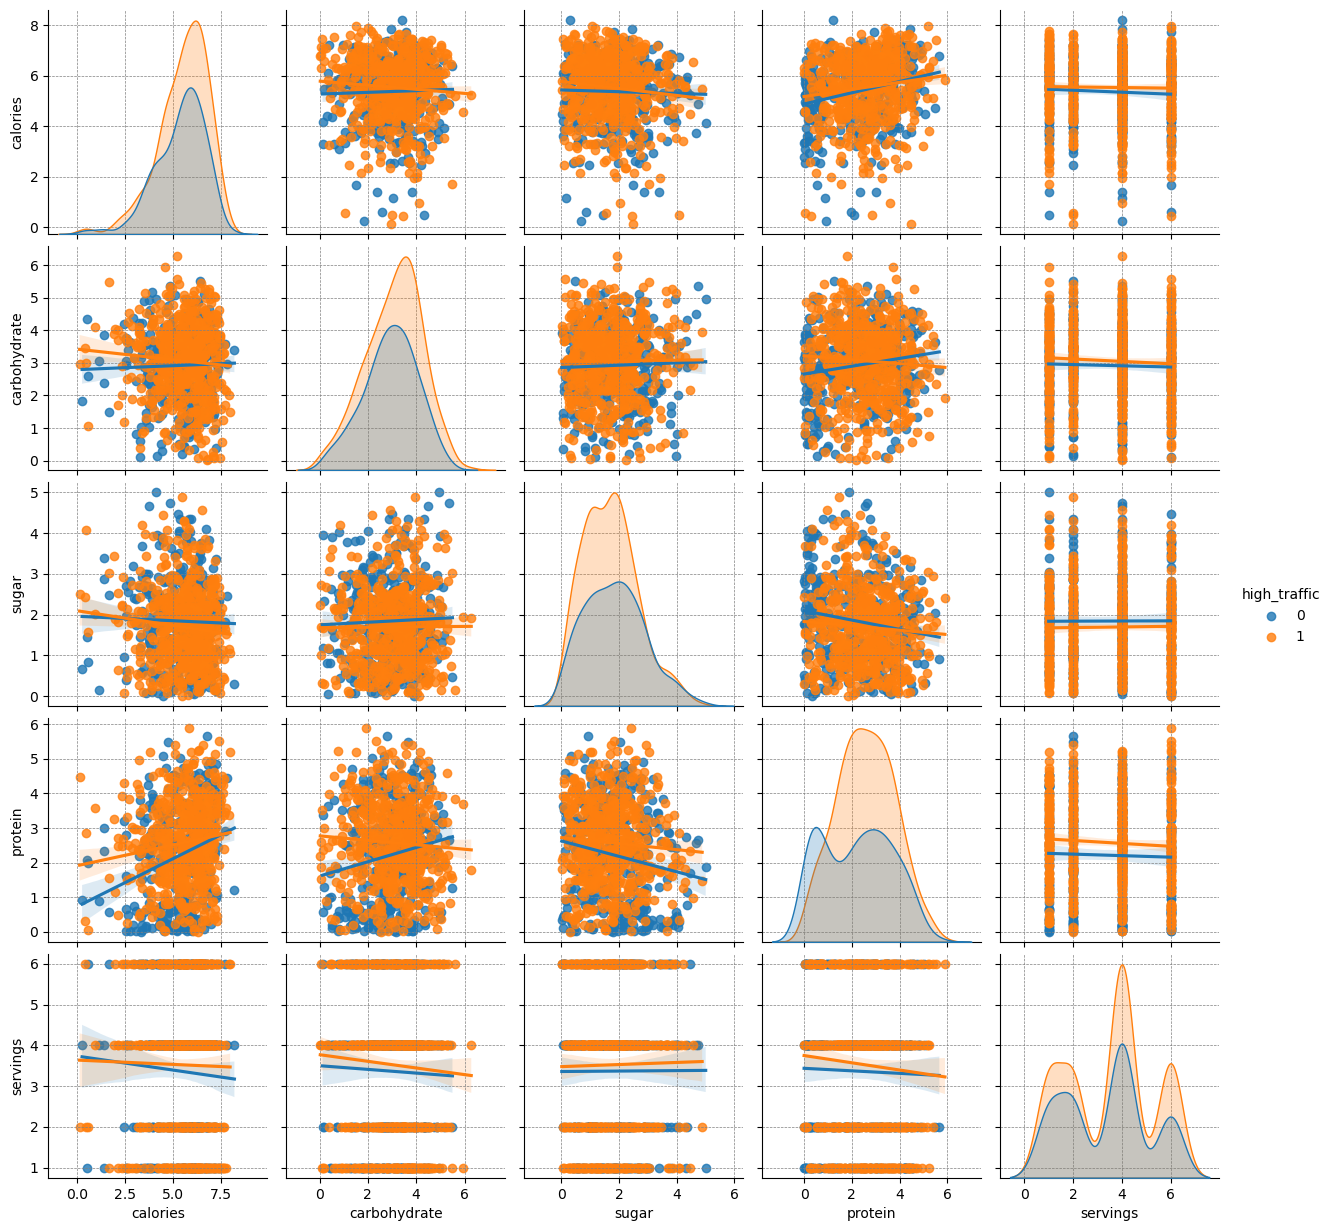

R-squared for calories: 0.0038
R-squared for carbohydrate: 0.0036
R-squared for sugar: 0.0054
R-squared for protein: 0.0179
R-squared for servings: 0.0019


In [276]:
sns.pairplot(data=numerical_variables, hue='high_traffic', kind='reg', diag_kind='kde')
for ax in plt.gcf().axes:
    ax.grid(True, linestyle='--', color='gray', linewidth=0.5)   
plt.show()

# import statsmodels.api as sm

tasty_nums = tasty_3.select_dtypes(include = ['float64', 'int64']).drop('recipe', axis = 1)

# print(tasty_nums)

f= tasty_nums['high_traffic']
f = sm.add_constant(f)

for col in tasty_nums:
    
    if col != 'high_traffic':
    
            

            # print(X)
            model = sm.OLS(tasty_nums[col], f).fit()
            r_squared = round(model.rsquared, 4)

            print(f'R-squared for {col}: {r_squared}')

<b>Interpretation</b>

<ul>
  <li>An R² of 0.5 (50%) would mean that the independent variable(s) explain 50% of the variability in the dependent variable.</li>
  <li>An R² of 1 (100%) would mean that the model perfectly predicts the dependent variable.</li>
  <li>An R² of 0 means that the model does not explain any of the variability in the dependent variable.</li>
</ul>

<p>
Unfortunately the r-squareds are close to zero.<br>
This means a linear regression model is not a good fit for predicting high_traffic.
</p>


In [277]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = numerical_variables 
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

        Feature        VIF
0      calories  10.446275
1  carbohydrate   6.383446
2         sugar   3.678368
3       protein   4.496676
4      servings   4.342665
5  high_traffic   2.525883


<b>Interpretation</b>

<ul>
  <li><strong>VIF &lt; 5</strong>: Generally considered acceptable. This suggests that there is low multicollinearity, meaning the independent variables are not highly correlated with each other, and the model is not significantly affected by multicollinearity.</li>
  <li><strong>VIF between 5 and 10</strong>: Indicates moderate multicollinearity. This suggests that multicollinearity is present but might still be acceptable depending on the context.</li>
  <li><strong>VIF &gt; 10</strong>: Indicates high multicollinearity, suggesting that the independent variables are highly correlated. This can make it difficult to distinguish the individual effects of the variables on the dependent variable.</li>
</ul>

<p>
All VIFs are below 5.<br>
This indicates a low multicollinearity.<br>
</p>

<h3>Point-Biserial correlation</h3>

<p>
is still measuring a linear relationship, but the predictors are continuous and the target
is bivariate.
</p>

<p>
"The point biserial correlation coefficient (rpb) is a correlation coefficient used when one variable (e.g. Y) is dichotomous; Y can either be "naturally" dichotomous, like whether a coin lands heads or tails, or an artificially dichotomized variable. In most situations it is not advisable to dichotomize variables artificially. When a new variable is artificially dichotomized the new dichotomous variable may be conceptualized as having an underlying continuity. If this is the case, a biserial correlation would be the more appropriate calculation."<br>
<b>Wikipedia</b>
</p>

Point-Biserial Correlation: 0.06203075310139112, P-value: 0.06360490769300002
            var  point_corr  point_p_value
0      calories        0.06           0.06
1  carbohydrate        0.06           0.07
2         sugar       -0.07           0.03
3       protein        0.13           0.00
4      servings        0.04           0.20


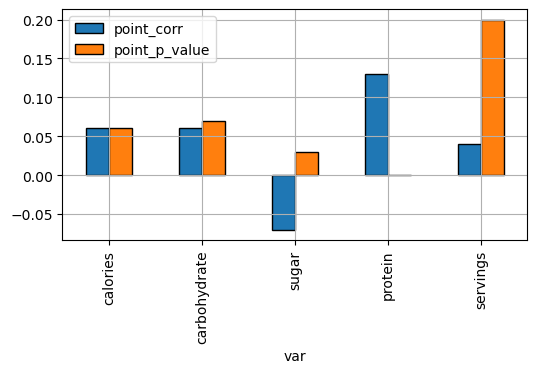

In [278]:
from scipy.stats import pointbiserialr

# Calculate Point-Biserial Correlation for a continuous variable (e.g., calories)
corr, p_value = \
pointbiserialr(numerical_variables['calories'], numerical_variables['high_traffic'])
print(f"Point-Biserial Correlation: {corr}, P-value: {p_value}")


numerical_variables.columns.tolist()[:4]

point_dict = {}

for col in numerical_variables.drop('high_traffic', axis=1):
    
    target = numerical_variables['high_traffic']
    point_corr, point_p_value = pointbiserialr(numerical_variables[col], target)
    
    # Store point_corr and point_p_value for each column
    point_dict[col] = {'point_corr': round(point_corr, 2), \
                       'point_p_value': round(point_p_value, 2)}


point_df = \
pd.DataFrame.from_dict(point_dict, orient='index').reset_index().\
rename(columns={'index': 'var'})

print(point_df)

point_df.plot.bar(x='var', figsize = (6, 3), edgecolor='black', grid=True)
plt.show()

<h3>Interpretation:</h3>
<ul>
    <li>A <strong>positive Point-Biserial correlation</strong> means that as the continuous variable increases, the binary variable is more likely to be 1 (or "true").</li>
    <li>A <strong>negative Point-Biserial correlation</strong> means that as the continuous variable increases, the binary variable is more likely to be 0 (or "false").</li>
    <li>A correlation close to <strong>0</strong> indicates little to no linear relationship.</li>
</ul>

<b>Conclusion Point-Biserial correlations</b>
<p>
Calories, Carbohydrate, Sugar have p-values smaller 0.05, the null is rejected,<br>
and the correlations are deemed statistical significant.<br>
However, the correlations are weak.<br>
Therefore a linear model seems not a good idea, even in terms of the Point-Biserial correlations.
</p>

<h3>Conclusions data exploration of linear relationships</h3>

<p>
Linear models are not a good fit.<br>
This was to be expected.<br>
As the target variable is bivariate and regression models need continuous variables,<br>
non-linear models are prefered anyway.<br>
Encoding and normalization is useful.
</p>

<h3>Exploring non-linear relationships in the data</h3>
<h3>Exploring the Target Variable</h3>

In [279]:
print(target.value_counts())

high_traffic
1    535
0    360
Name: count, dtype: int64


high_traffic
1    535
0    360
Name: count, dtype: int64


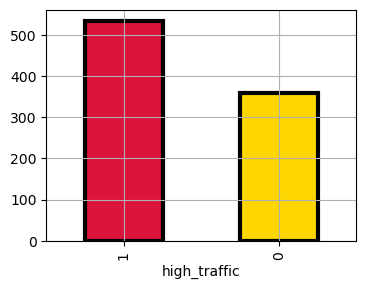

count    895.000000
mean       0.597765
std        0.490623
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: high_traffic, dtype: float64


In [280]:
high = tasty_3['high_traffic'].value_counts()

print(high)

high.plot.bar(edgecolor='black', linewidth=3, grid=True, figsize=(4,3),
              color=['crimson', 'gold'])
plt.show()

print(target.describe())
# The mean is not 0.5. This indicates an imbalanced class,
# where one value of the bivariate variable is more represented in the data than the others

<b>Insights</b>

<ul>
        <li>Imbalanced classes but not strongly.</li>
        <li>Evaluation with accuracy alone could be misleading as the majority class
            appear more often.</li>
        <li>Complement with recall and precision.</li>
        <li>Balancing classes maybe necessary.</li>
</ul>

In [281]:
high_traffic_recipes = tasty_3[['recipe', 'high_traffic']]
# help(tasty_3['high_traffic'].value_counts)

<h3>Exploring the categorical Variable</h3>

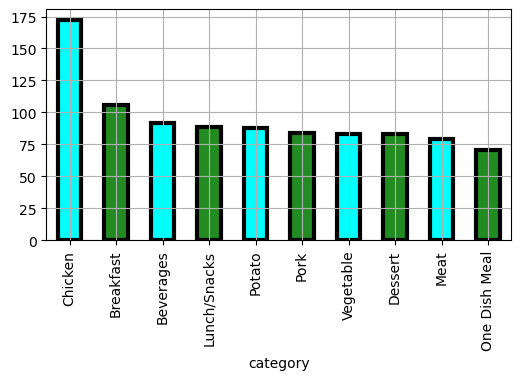

In [282]:
tasty['category'].value_counts()
tasty['category'].value_counts().\
plot.bar(edgecolor='black', linewidth=3, color=['cyan', 'forestgreen'],
         grid=True, figsize=(6,3))
plt.show()

In [283]:
crosstab_category = \
pd.crosstab(tasty_3['category'], tasty_3['high_traffic'], normalize='index').\
round(2)*100

crosstab_category

high_traffic,0,1
category,,
Beverages,95.0,5.0
Breakfast,69.0,31.0
Chicken,58.0,42.0
Dessert,38.0,62.0
Lunch/Snacks,37.0,63.0
Meat,24.0,76.0
One Dish Meal,24.0,76.0
Pork,10.0,90.0
Potato,6.0,94.0


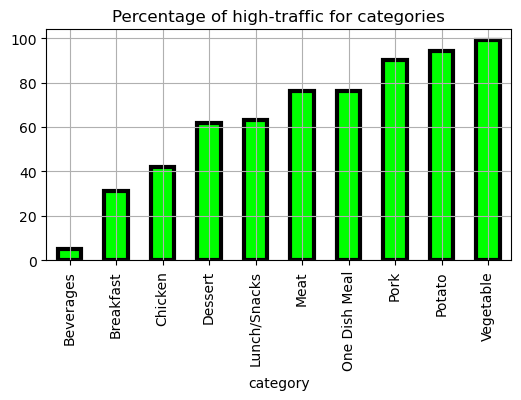

In [284]:
plt.figure(figsize=(6,3))
crosstab_category[1].plot.bar(edgecolor='black', linewidth=3, 
                              title="Percentage of high-traffic for categories",
                              color='lime')
plt.grid()
plt.show()

<b>Insights</b>

<ul>
        <li>Association between high-traffic and category, when proportion greater 50%.</li>
        <li>If greater 60 category could be a predictor for high-traffic.</li>
        <li>Vegetables correlated with high-traffic?</li>
</ul>

<h3>chi2 test</h3> 
<p>
for measuring the association between category and high-traffic.
</p>

In [285]:
from scipy.stats import chi2_contingency

# Perform the chi-square test
chi2, p, dof, ex = chi2_contingency(crosstab_category)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p}")

Chi-Square Statistic: 352.77715235802486
P-value: 1.588806211652333e-70


<b>Insights</b>

<ul>
        <li>Reject the Null-Hypothesis.<br> 
            It is extremly unlikely to observe a p-value so small
            if the Null would be true.</li>
        <li>There is an association between high-traffic and recipe category displays.</li>
        <li>The category variable is a strong predictor or feature.</li>
</ul>

<h3>Visualisation of the category and high-traffic variables</h3>

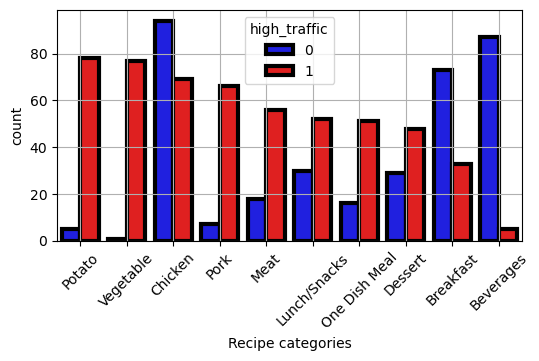

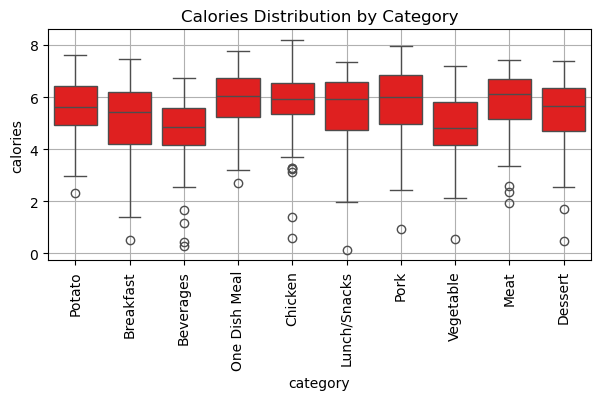

In [286]:
sort_1 = tasty_3['category'].value_counts().index
tasty_high_cat = tasty_3[['category', 'high_traffic']]

sort_1 = tasty_high_cat[tasty_high_cat['high_traffic'] == 1]['category'].value_counts().index

plt.figure(figsize=(6,3))
sns.countplot(x='category', hue='high_traffic', data=tasty_high_cat,
              edgecolor='black', linewidth=3, order=sort_1, palette=["blue", "red"])
plt.grid(True)
plt.xlabel("Recipe categories")
plt.xticks(rotation=45)
plt.show()


# Boxplot to compare calories distribution across categories 
plt.figure(figsize=(7,3))
sns.boxplot(x='category', y='calories', data=tasty_3, color='red')
plt.xticks(rotation=90)
plt.grid()
plt.title('Calories Distribution by Category')
plt.show()



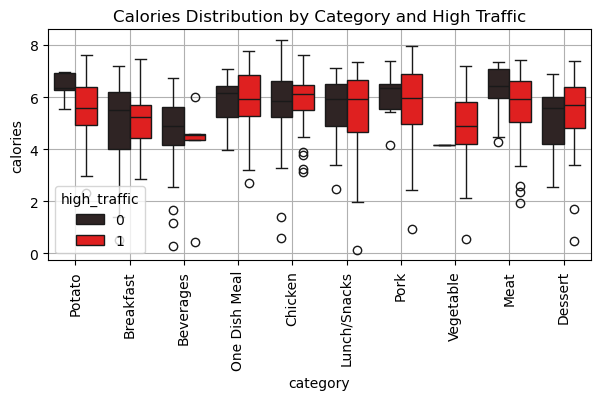

In [287]:
# Boxplot to compare calories distribution across categories and high traffic
plt.figure(figsize=(7,3))
sns.boxplot(x='category', y='calories', data=tasty_3, palette='dark:red', hue='high_traffic')
plt.xticks(rotation=90)
plt.grid()
plt.title('Calories Distribution by Category and High Traffic')
plt.show()


<b>Conclusion:</b><br>
<p>
The medians of both groups are close together, indicating that the central tendencies of the calorie distribution are similar across the two groups.<br>
The interquartile ranges (IQRs) are inversely related: when the IQR of one group is larger, the other group's IQR is smaller, and vice versa.<br>
This suggests that the variability in calorie distribution is inversely related between the two groups.<br>
Outliers are present in the data, but they are reflective of real-world variations in recipes rather than issues with data collection or sampling.<br>
For machine learning, data transformations such as scaling or normalization could be considered to handle the differences in variability.
</p>

<h3>Pairwise independent Welsh t-test</h3>

<p>
of low traffic and high traffic variables.<br>
The goal is to determine if there is a statistical difference 
in presence of the variable in question, when high-traffic is 1 or 0.
</p>


<p>
As the histograms are skewed the normality assumption is undermined<br>
and the Welsh t-test is applied hear with equal variances = False.
</p>


In [288]:
n_var_names = numerical_variables.columns.tolist()[0:4]
high_df = numerical_variables[numerical_variables['high_traffic'] == 1]
low_df = numerical_variables[numerical_variables['high_traffic'] == 0]

for var in n_var_names:
    t_stat, p_val = ttest_ind(low_df[var], high_df[var], equal_var=False)
    
    print(f'T-test for {var}')
    print(f'T-statistic: {round(t_stat, 2)}, p_value: {round(p_val, 4)}') 
    print(f"{'Reject Null-hypothesis' if p_val < 0.05 else 'Accept Null-Hypothesis'}")
    print('--------------------------------------')

T-test for calories
T-statistic: -1.86, p_value: 0.0633
Accept Null-Hypothesis
--------------------------------------
T-test for carbohydrate
T-statistic: -1.82, p_value: 0.0688
Accept Null-Hypothesis
--------------------------------------
T-test for sugar
T-statistic: 2.16, p_value: 0.0308
Reject Null-hypothesis
--------------------------------------
T-test for protein
T-statistic: -3.89, p_value: 0.0001
Reject Null-hypothesis
--------------------------------------


<p>
Calories<br>
Xmean-1 - Xmean-2 = T-statistic<br>
Xmean-1: low traffic / Xmean-2: high traffic
</p>


<b>Insights</b>

<ul>
<li>T-test for calories indicates that high-traffic recipes tend to have more calories than low-traffic recipes on average.</li>
<li>T-test for carbohydrate indicates that high-traffic recipes tend to have more carbohydrate than high-traffic recipes on average.</li>
<li>T-test for sugar indicates that low-traffic recipes tend to have more sugar than high-traffic recipes on average.</li>
    
<li>All variables are statistically significant with regard to the p-values and should be included as features in a machine learning model. </li>   
</ul>

<h3>Mann-Whitney U Test</h3>

<p>
is here used to assess if there are significant differences between the two groups (high_traffic = 0 and high_traffic = 1) given continuous features that do not show a linear relationship with the binary target. The histograms show skewed distributions.
</p>


In [289]:
from scipy.stats import mannwhitneyu

man_dict = {}


for col in n_var_names:
    # print(col)
    # print(high_df[col])
    high_group = high_df[col]
    low_group = low_df[col]
    stat, p_value = mannwhitneyu(low_group, high_group )
    man_dict[col] = {'u-statistic': round(stat, 2), 'p_value': round(p_value, 2)}
    
man_df = pd.DataFrame.from_dict(man_dict, orient='index')

man_df['sig_test'] = np.where(man_df['p_value'] > 0.05, 0, 1)


print('mannwhitneyu - test - results')
print('----------------------------------------------------------------------------')
print(man_df)
print('----------------------------------------------------------------------------')
print(f'significance_test: alpha = 0.05, 0: accept the Null, 1: reject the Null')

mannwhitneyu - test - results
----------------------------------------------------------------------------
              u-statistic  p_value  sig_test
calories          88456.5     0.04         1
carbohydrate      88945.0     0.05         1
sugar            104355.0     0.03         1
protein           82762.5     0.00         1
----------------------------------------------------------------------------
significance_test: alpha = 0.05, 0: accept the Null, 1: reject the Null


In [290]:
# check
100+201

301

<b>Interpretation</b>

<p>
For the high_traffic and low_traffic recipies there is significant 
difference in protein and calories.<br>
As features those could help to differentiate between high_traffic and low_traffic recipies
on the website.
</p>

<h3>Conclusions data exploration of non-linear relationships</h3>

<p>
There are valuable predictor, independent variables in the data set.<br>
Encoding and normalization is useful.
</p>
<h1>Data preprocessing</h1>

<h2>Encoding of categorical variable: category</h2>


In [291]:
from sklearn.preprocessing  import OneHotEncoder
# from sklearn.preprocessing import OneHotEncoder

ohe_category = OneHotEncoder(handle_unknown = 'error', drop='first', sparse_output=False)
ohe_category_array = ohe_category.fit_transform(pd.DataFrame(tasty_3['category']))
print(ohe_category.categories_)

ohe_feature_names = ohe_category.get_feature_names_out()

ohe_category_df = pd.DataFrame(ohe_category_array, columns = ohe_feature_names)

ohe_category_df.info()

ohe_category_df.iloc[:2, 0:4]

ohe_category_df.iloc[:2, 5:9]

# help(OneHotEncoder)

# tasty_4_encoded = tasty_3.copy()

tasty_4_encoded = pd.concat([tasty_3, ohe_category_df], axis=1)

# category is encoded and is therefore dropped
tasty_4_encoded.drop('category', axis=1, inplace=True)

print(tasty_4_encoded.info())

tasty_4_encoded.head()

[array(['Beverages', 'Breakfast', 'Chicken', 'Dessert', 'Lunch/Snacks',
       'Meat', 'One Dish Meal', 'Pork', 'Potato', 'Vegetable'],
      dtype=object)]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   category_Breakfast      895 non-null    float64
 1   category_Chicken        895 non-null    float64
 2   category_Dessert        895 non-null    float64
 3   category_Lunch/Snacks   895 non-null    float64
 4   category_Meat           895 non-null    float64
 5   category_One Dish Meal  895 non-null    float64
 6   category_Pork           895 non-null    float64
 7   category_Potato         895 non-null    float64
 8   category_Vegetable      895 non-null    float64
dtypes: float64(9)
memory usage: 63.1 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 16 columns):
 #   Colum

,recipe,calories,carbohydrate,sugar,protein,servings,high_traffic,category_Breakfast,category_Chicken,category_Dessert,category_Lunch/Snacks,category_Meat,category_One Dish Meal,category_Pork,category_Potato,category_Vegetable
0,2,3.596764,3.677819,0.506818,0.652325,4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3,6.819230,3.776890,1.408545,1.355835,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,4.585274,3.451890,3.679586,0.019803,4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,3.333989,1.047319,0.587787,0.425268,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6,6.539803,1.495149,0.974560,4.006060,2,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


<h3>Feature Engineering</h3>

<p><strong>Using Interaction Terms</strong></p>
<p>Interaction terms capture the combined effect of multiple features. For example, calories and sugar together might influence traffic more than each feature alone. By adding interaction terms, the model can learn these combined patterns, potentially improving accuracy.</p>


In [292]:
from sklearn.preprocessing import PolynomialFeatures

# Select only the numerical columns for interaction term creation
num_features = tasty_4_encoded[['calories', 'carbohydrate', 'protein', 'sugar']]

# Generate interaction terms up to degree 2
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
num_interactions = poly.fit_transform(num_features)

# Convert back to DataFrame with proper names
interaction_df = pd.DataFrame(num_interactions, columns=poly.get_feature_names_out(num_features.columns))

# Add interaction terms to the main DataFrame
tasty_4_encoded = pd.concat([tasty_4_encoded, interaction_df], axis=1)

print(tasty_4_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   recipe                  895 non-null    int64  
 1   calories                895 non-null    float64
 2   carbohydrate            895 non-null    float64
 3   sugar                   895 non-null    float64
 4   protein                 895 non-null    float64
 5   servings                895 non-null    int64  
 6   high_traffic            895 non-null    int64  
 7   category_Breakfast      895 non-null    float64
 8   category_Chicken        895 non-null    float64
 9   category_Dessert        895 non-null    float64
 10  category_Lunch/Snacks   895 non-null    float64
 11  category_Meat           895 non-null    float64
 12  category_One Dish Meal  895 non-null    float64
 13  category_Pork           895 non-null    float64
 14  category_Potato         895 non-null    fl

<h2>Train-Test-Split</h2>

In [293]:
from sklearn.model_selection import train_test_split

features = tasty_4_encoded.drop(['high_traffic'], axis = 1)
print(features.info())

target = tasty_4_encoded['high_traffic']
# print(target.describe())


X_train, X_test, y_train, y_test = \
train_test_split(features, target, test_size=0.2, random_state=42)

recipe_train = X_train['recipe']
recipe_test = X_test['recipe']

X_train = X_train.drop('recipe', axis = 1)
X_test = X_test.drop('recipe', axis = 1)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   recipe                  895 non-null    int64  
 1   calories                895 non-null    float64
 2   carbohydrate            895 non-null    float64
 3   sugar                   895 non-null    float64
 4   protein                 895 non-null    float64
 5   servings                895 non-null    int64  
 6   category_Breakfast      895 non-null    float64
 7   category_Chicken        895 non-null    float64
 8   category_Dessert        895 non-null    float64
 9   category_Lunch/Snacks   895 non-null    float64
 10  category_Meat           895 non-null    float64
 11  category_One Dish Meal  895 non-null    float64
 12  category_Pork           895 non-null    float64
 13  category_Potato         895 non-null    float64
 14  category_Vegetable      895 non-null    fl

In [294]:
recipe_test.shape

(179,)

<h3>Class balancing and SMOTE</h3>

<p>
As explained above the classes of the target variable are imbalanced.
This can lead to distortions in the predictions. A method to balancing classes is the
"SMOTE"- technique.
</p>


<p>Class balancing and the use of SMOTE (Synthetic Minority Over-sampling Technique) are crucial steps in addressing class imbalance in machine learning models. When a dataset has significantly more samples from one class than the other (imbalanced classes), the model may become biased towards predicting the majority class, leading to poor performance on the minority class.</p>

<p>SMOTE is an over-sampling technique that helps mitigate this issue by generating synthetic samples for the minority class. Instead of simply duplicating existing samples, SMOTE creates new instances by interpolating between neighboring data points in the feature space. This helps improve the model's ability to learn from the minority class and results in more balanced class distributions, enhancing model performance and generalization.</p>


In [295]:

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


print(X_train_smote.shape, y_train_smote.shape)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(858, 24) (858,)
(716, 24) (716,)
(179, 24) (179,)


In [296]:
print(y_train_smote.value_counts())

high_traffic
1    429
0    429
Name: count, dtype: int64


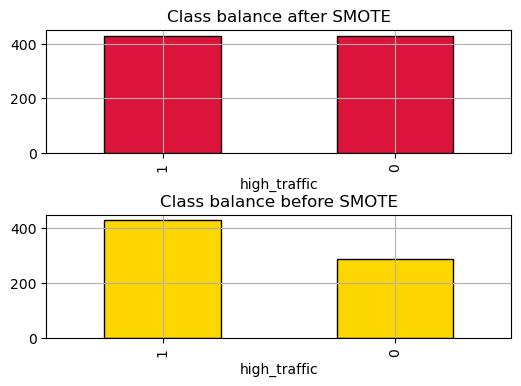

In [297]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(6, 4))

y_train_smote.value_counts().\
plot.bar(edgecolor='black',
color='crimson', title="Class balance after SMOTE", ax=ax1)
ax1.grid(True)

y_train.value_counts().\
plot.bar(edgecolor='black',
color='gold', title="Class balance before SMOTE", ax=ax2)
ax2.grid(True)

plt.subplots_adjust(hspace=0.5)

plt.show()

<h2>Normalization</h2>

<p>
is necessary, when features differ in size substantially.<br>
This can harm the performance of the ML algos.<br>
Possibly the the feature with the higher number would dominate the calculations.<br>
Everytime all features are normalized, when doing this and not only a subset.<br>
</p>

<p>
The recipe var is a unique identifier.<br>
It is there not a predictor var.<br>
The goal is to add the recipe back to the prediction of the target var.<br>
For this reason the unique identifier recipe is kept before the split.
Otherwise shuffling during split could distort the index.
The recipe var is afterwards stored.
</p>

(858, 24)
(179, 24)


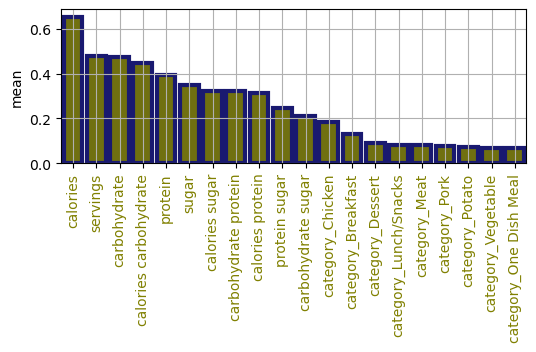

In [298]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns) 
# Adjusting the names to the array by transforming the array to the df

# Transform the test data using the same scaler (do not fit again)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)  

max_feature_values = scaler.data_max_
min_feature_values = scaler.data_min_


# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

X_train_scaled_means = \
pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().iloc[1].\
sort_values(ascending=False)


plt.figure(figsize=(6,2))
sns.barplot(X_train_scaled_means, color='olive', linewidth=3, 
            edgecolor='midnightblue')
plt.xticks(rotation=90, color='olive')
plt.grid(True)
plt.show()

<h2>Modeling</h2>

<p>
In machine learning, modeling refers to the process of building a mathematical or computational representation (a model) that can learn from and make predictions based on data. A model captures the relationships and patterns within the data so that it can generalize and make predictions on new, unseen data.
</p>

<h3>Section 3: Model development</h3>

<p>Model development in machine learning refers to the process of creating, training, and refining models to make predictions or decisions based on data. It typically involves several key steps:</p>

<ul>
    <li><strong>Data Preparation:</strong> Cleaning, transforming, and splitting the data into training and testing sets.</li>
    <li><strong>Model Selection:</strong> Choosing an appropriate algorithm based on the problem type (e.g., classification, regression).</li>
    <li><strong>Training:</strong> Feeding the training data into the model so it can learn patterns and relationships.</li>
    <li><strong>Evaluation:</strong> Assessing the model’s performance on the test data using metrics such as accuracy, precision, or recall.</li>
    <li><strong>Model Tuning:</strong> Adjusting model parameters and hyperparameters to improve performance.</li>
    <li><strong>Iteration:</strong> Repeating these steps, often experimenting with different models, features, or algorithms, until an optimal solution is found.</li>
</ul>


<h3>Model 1: Logistic Regression - Development</h3>
<p>
Logistic regression is often used as a starting point to establish a baseline performance. It’s a simple and interpretable model, allowing you to set a reference point against which more complex models can be compared. If a more complex model significantly outperforms logistic regression, it’s a good indicator that the complexity is warranted.
</p>

<p>
    <b>Logistic Regression (aka logit, MaxEnt) classifier.</b>
</p>

<p>
class LogisticRegression(sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)<br>
 </p>
 <p>
LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)
 </p>

In [299]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay

logreg_1 = LogisticRegression(class_weight='balanced')

logreg_1.fit(X_train_scaled, y_train_smote)
logreg_1_preds = logreg_1.predict(X_test_scaled)

print(logreg_1_preds.shape)
print(logreg_1_preds[:10])
logreg_1_proba_preds = logreg_1.predict_proba(X_test_scaled)

# print(logreg_1_proba_preds.shape)
# print(logreg_1_proba_preds[:5

logreg_1_proba_preds_df = pd.DataFrame(logreg_1_proba_preds, 
                                       columns=['Proba 0', 'Proba 1'])
logreg_1_preds_df = pd.DataFrame(logreg_1_preds, columns=['Prediction'])

logreg_1_preds_df = \
pd.concat([logreg_1_proba_preds_df, logreg_1_preds_df], axis=1).\
round(2)

logreg_1_preds_df.head()

(179,)
[1 0 0 1 0 1 1 1 0 0]


,Proba 0,Proba 1,Prediction
0,0.47,0.53,1
1,0.57,0.43,0
2,0.86,0.14,0
3,0.36,0.64,1
4,0.74,0.26,0


<ul>
    
<li>
Proba 0: This column shows the predicted probability that a sample belongs to class 0.
</li>
<li>
Proba 1: This column shows the predicted probability that a sample belongs to class 1.
</li>
<li>
Prediction: This column shows the final predicted class based on the probabilities.
</li>
    
</ul>

<h3>Model 1A: Logistic Regression - Evaluation</h3>

0.74
0.79
0.75
                 model_1
accuracy_score      0.74
recall_score        0.79
precision_score     0.75
[[52 26]
 [21 80]]


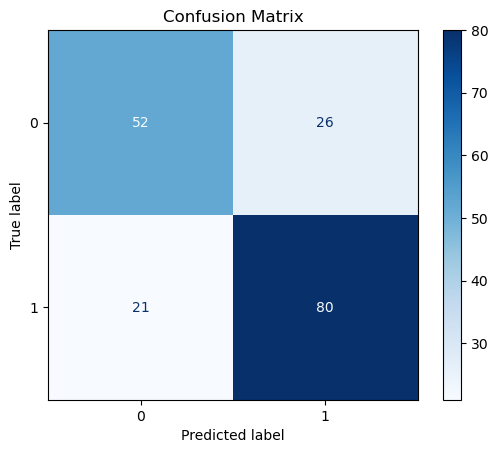

              precision    recall  f1-score    support
0              0.666667  0.712329  0.688742   73.00000
1              0.792079  0.754717  0.772947  106.00000
accuracy       0.737430  0.737430  0.737430    0.73743
macro avg      0.729373  0.733523  0.730844  179.00000
weighted avg   0.740933  0.737430  0.738606  179.00000


In [300]:
logreg_1_preds_df['Prediction'].value_counts()
# from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

# logreg_1_preds
# y_test

accuracy_score_1 = round(accuracy_score(logreg_1_preds, y_test), 2)
print(accuracy_score_1)

recall_score_1 = round(recall_score(logreg_1_preds, y_test), 2)
print(recall_score_1)

precision_score_1 = round(precision_score(logreg_1_preds, y_test), 2)
print(precision_score_1)

confusion_matrix_1 = confusion_matrix(logreg_1_preds, y_test)

scores_df = \
pd.DataFrame({'model_1': [accuracy_score_1, recall_score_1, precision_score_1]}, 
             index=['accuracy_score', 'recall_score', 'precision_score'])


print(scores_df )

cm_1 = confusion_matrix_1
print(cm_1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_1)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

import pandas as pd
from sklearn.metrics import classification_report

# classification report 
report_dict = classification_report(y_test, logreg_1_preds, output_dict=True)

classification_report_df = pd.DataFrame(report_dict).transpose()

print(classification_report_df)


<h3>Model 1B: Logistic Regression - Development - Hypertuning</h3>

In [301]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.linear_model import LogisticRegression

logreg_2_hyper = LogisticRegression()
# help(LogisticRegression)

<b> GridSearchCV</b>
<p>
class GridSearchCV(BaseSearchCV)
GridSearchCV(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)
                </p>
    <p>
Exhaustive search over specified parameter values for an estimator.
                </p>
        <p>
Important members are fit, predict.
                </p>
            <p>
GridSearchCV implements a "fit" and a "score" method.
It also implements "score_samples", "predict", "predict_proba",
"decision_function", "transform" and "inverse_transform" if they are
implemented in the estimator used.
                </p>

In [302]:
# Set different parameters

logreg_2_hyper = LogisticRegression()

param_grid_logreg= {

"C": [0.001, 0.01, 0.1, 1000], # regularization strength
"penalty": ['l1', 'l2'], # regularization type
"solver": ['liblinear', 'saga'], # solver types
"max_iter": [100, 200, 100000000] # maximum iterations
}


grid_search_logreg_2 = GridSearchCV(estimator=logreg_2_hyper, param_grid=param_grid_logreg,refit='recall', cv=10, scoring='recall', error_score='raise')

import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

grid_search_logreg_2.fit(X_train_scaled, y_train_smote)

print(grid_search_logreg_2.best_params_)
print("Recall:", grid_search_logreg_2.best_score_)
print("Best estimator:", grid_search_logreg_2.best_estimator_)


{'C': 0.001, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Recall: 0.9230897009966779
Best estimator: LogisticRegression(C=0.001, solver='liblinear')


In [303]:
best_logreg_model = grid_search_logreg_2.best_estimator_

# predictions
y_pred = best_logreg_model.predict(X_test_scaled)

# Calculate recall
recall = recall_score(y_test, y_pred, pos_label=1)
print(f'Recall for high-traffic class with best hyperparameters: {recall:.2f}')

Recall for high-traffic class with best hyperparameters: 0.89


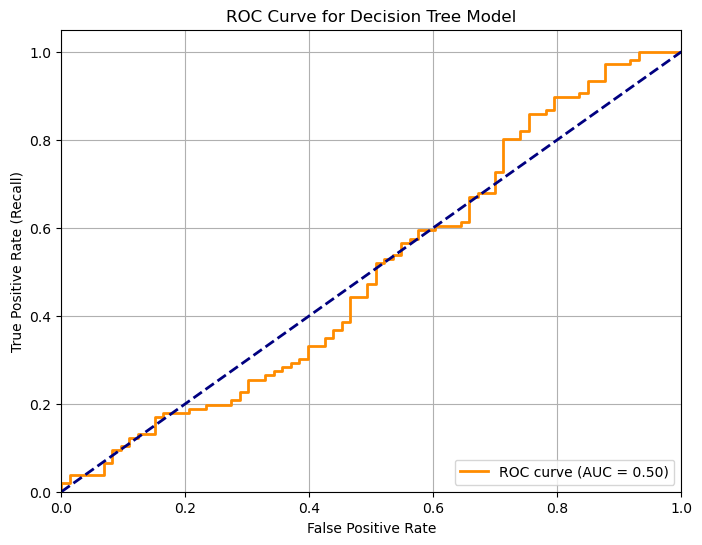

In [304]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# probabilities  positive class
y_pred_proba = best_logreg_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for Decision Tree Model')
plt.legend(loc="lower right")
plt.grid()
plt.show()


<p>
The hypertuned model did produce a recall of 0.88 <br>
</p>


<h3>Model 1c: DecisionTreeClassifier - Development</h3>

In [305]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
tree_model.fit(X_train_smote, y_train_smote)

# Make predictions on the test set
y_pred = tree_model.predict(X_test)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

recall = recall_score(y_test, y_pred, pos_label=1)
print(f'Recall for high-traffic class: {recall:.2f}')


Accuracy: 0.664804469273743
Recall for high-traffic class: 0.68


<h3>Model 1d: DecisionTreeClassifier - HyperTuning</h3>

In [306]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Model DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)

# hyperparameters
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=tree_model, param_grid=param_grid, 
                           cv=10, scoring='accuracy', n_jobs=-5, verbose=1)

# Fit the model on the training data (with SMOTE)
grid_search.fit(X_train_scaled, y_train_smote)

# Best hyperparameters
print("Best hyperparameters:", grid_search.best_params_)

# Predict on the test set using the best model
best_tree_model = grid_search.best_estimator_
y_pred = best_tree_model.predict(X_test)

# y_pred_proba = best_logreg_model.predict_proba(X_test)[:, 1]
y_pred_proba_tree = best_tree_model.predict_proba(X_test)[:, 1]

# Evaluate the accuracy of the best model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy with best hyperparameters: {accuracy}')

recall = recall_score(y_test, y_pred, pos_label=1)
print(f'Recall for high-traffic class: {recall:.2f}')



Fitting 10 folds for each of 72 candidates, totalling 720 fits
Best hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy with best hyperparameters: 0.7206703910614525
Recall for high-traffic class: 0.82


In [307]:
DecisionTreeClassifier_confusion_matrix = confusion_matrix(y_test, y_pred)
print(DecisionTreeClassifier_confusion_matrix)

DecisionTreeClassifier_classification_report = classification_report(y_test, y_pred)
print(DecisionTreeClassifier_classification_report)

[[42 31]
 [19 87]]
              precision    recall  f1-score   support

           0       0.69      0.58      0.63        73
           1       0.74      0.82      0.78       106

    accuracy                           0.72       179
   macro avg       0.71      0.70      0.70       179
weighted avg       0.72      0.72      0.72       179



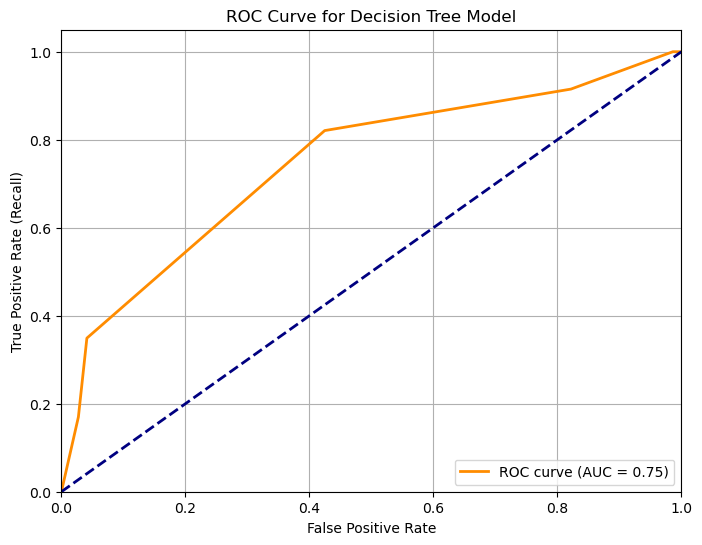

In [308]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Compute ROC curve and ROC area

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_tree)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for Decision Tree Model')
plt.legend(loc="lower right")
plt.grid()
plt.show()


<h3>Model 1e: Support Vector Machine - development</h3>

(179,)
[1 1 0 1 0 1 1 1 0 0]
   Proba 0  Proba 1  Prediction
0     0.20     0.80           1
1     0.26     0.74           1
2     0.69     0.31           0
3     0.21     0.79           1
4     0.76     0.24           0
Accuracy: 0.76
Recall: 0.80
Precision: 0.79


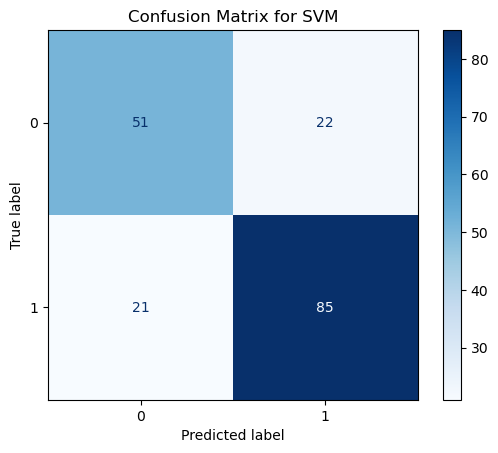

In [309]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# Initialize SVM with balanced class weight
svm_model = SVC(class_weight='balanced', probability=True, random_state=42)

# Fit the model
svm_model.fit(X_train_scaled, y_train_smote)

# Make predictions
svm_preds = svm_model.predict(X_test_scaled)
print(svm_preds.shape)
print(svm_preds[:10])

# Get probabilities
svm_proba_preds = svm_model.predict_proba(X_test_scaled)

# Convert predictions and probabilities into DataFrame
svm_proba_preds_df = pd.DataFrame(svm_proba_preds, columns=['Proba 0', 'Proba 1'])
svm_preds_df = pd.DataFrame(svm_preds, columns=['Prediction'])
svm_preds_df = pd.concat([svm_proba_preds_df, svm_preds_df], axis=1).round(2)

# Display the first few rows
print(svm_preds_df.head())

# Evaluate model
accuracy = accuracy_score(y_test, svm_preds)
recall = recall_score(y_test, svm_preds)
precision = precision_score(y_test, svm_preds)
print(f'Accuracy: {accuracy:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Precision: {precision:.2f}')

# Confusion matrix
confusion_matrix_svm = confusion_matrix(y_test, svm_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_svm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for SVM')
plt.show()


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters found:  {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Best cross-validated accuracy:  0.773969808241534
Accuracy on test set: 0.76
Recall on test set: 0.80
Precision on test set: 0.79


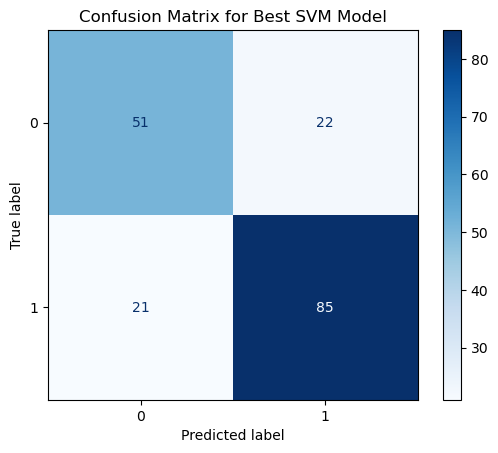

In [310]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Define the SVM model
svm_model = SVC(class_weight='balanced', probability=True, random_state=42)

# Define the hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],              # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel type
    'gamma': ['scale', 'auto'],           # Kernel coefficient for 'rbf', 'poly'
    'degree': [2, 3, 4]                   # Degree for 'poly' kernel
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train_smote)

# Get the best model and parameters
best_svm_model = grid_search.best_estimator_
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validated accuracy: ", grid_search.best_score_)

# Evaluate the best model on the test set
y_pred = best_svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
print(f'Accuracy on test set: {accuracy:.2f}')
print(f'Recall on test set: {recall:.2f}')
print(f'Precision on test set: {precision:.2f}')

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Best SVM Model')
plt.show()


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters found:  {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Best cross-validated accuracy:  0.773969808241534
Accuracy on test set: 0.76
Recall on test set: 0.80
Precision on test set: 0.79


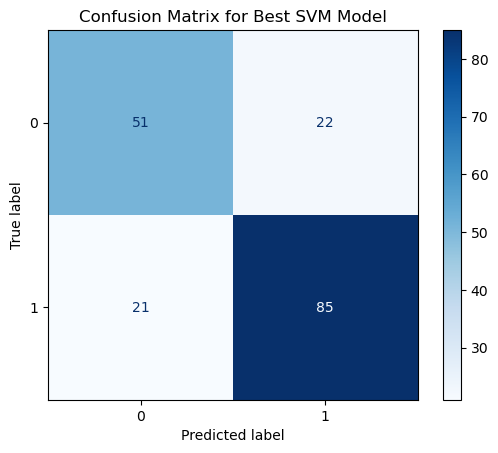

In [311]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Define the SVM model
svm_model = SVC(class_weight='balanced', probability=True, random_state=42)

# Define the hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],              # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel type
    'gamma': ['scale', 'auto'],           # Kernel coefficient for 'rbf', 'poly'
    'degree': [2, 3, 4]                   # Degree for 'poly' kernel
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train_smote)

# Get the best model and parameters
best_svm_model = grid_search.best_estimator_
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validated accuracy: ", grid_search.best_score_)

# Evaluate the best model on the test set
y_pred = best_svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
print(f'Accuracy on test set: {accuracy:.2f}')
print(f'Recall on test set: {recall:.2f}')
print(f'Precision on test set: {precision:.2f}')

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Best SVM Model')
plt.show()



<h3>Model 2A: Gradient Boosting Model - development of base model</h3>

<p>
without hypertuning.
</p>

In [312]:
gradient_model_1 = GradientBoostingClassifier(random_state=57)
gradient_model_1.fit(X_train_scaled, y_train_smote)
gradient_model_1_predictions = gradient_model_1.predict(X_test_scaled)

print(type(gradient_model_1_predictions))
print(gradient_model_1_predictions[:10])

gradient_1_accuracy_score = accuracy_score(y_test, gradient_model_1_predictions)

print(f'Accuracy of GradientBoostingClassifier: {gradient_1_accuracy_score}')
gradient_1_confusion_matrix = confusion_matrix(y_test, gradient_model_1_predictions)
print("Confusion matrix of GradientBoostingClassifier: \n",   gradient_1_confusion_matrix )
gradient_1_confusion_matrix_classification_report = classification_report(y_test, gradient_model_1_predictions)

print("Classification Report:\n", gradient_1_confusion_matrix_classification_report)

<class 'numpy.ndarray'>
[0 0 0 0 0 1 1 1 0 0]
Accuracy of GradientBoostingClassifier: 0.7150837988826816
Confusion matrix of GradientBoostingClassifier: 
 [[49 24]
 [27 79]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.67      0.66        73
           1       0.77      0.75      0.76       106

    accuracy                           0.72       179
   macro avg       0.71      0.71      0.71       179
weighted avg       0.72      0.72      0.72       179



<h3>Model 2B: Gradient Boosting Model - Development - Hypertuning</h3>

In [313]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 100],
    'learning_rate': [0.01, 0.1, 0.05],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=9,
                           n_jobs=-1,
                           scoring='accuracy')

# Fit GridSearch to the training data
grid_search.fit(X_train_scaled, y_train_smote)

# Best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Accuracy of Best Model:", accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))


Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}
Best Accuracy Score: 0.7798367446393761
Accuracy of Best Model: 0.6312849162011173
Confusion Matrix:
 [[27 46]
 [20 86]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.37      0.45        73
           1       0.65      0.81      0.72       106

    accuracy                           0.63       179
   macro avg       0.61      0.59      0.59       179
weighted avg       0.62      0.63      0.61       179



In [314]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the RandomForestClassifier without hyperparameter tuning
random_forest_model = RandomForestClassifier(random_state=57)

# Fit the model to the training data
random_forest_model.fit(X_train_scaled, y_train_smote)

# Make predictions on the test set
rf_predictions = random_forest_model.predict(X_test_scaled)

# Print the type of predictions and first 10 predictions
print(type(rf_predictions))
print(rf_predictions[:10])

# Calculate and print the accuracy score
rf_accuracy_score = accuracy_score(y_test, rf_predictions)
print(f'Accuracy of RandomForestClassifier: {rf_accuracy_score}')

# Generate and print the confusion matrix
rf_confusion_matrix = confusion_matrix(y_test, rf_predictions)
print("Confusion matrix of RandomForestClassifier: \n", rf_confusion_matrix)

# Generate and print the classification report
rf_classification_report = classification_report(y_test, rf_predictions)
print("Classification Report:\n", rf_classification_report)


<class 'numpy.ndarray'>
[0 0 0 1 0 1 1 1 0 0]
Accuracy of RandomForestClassifier: 0.6703910614525139
Confusion matrix of RandomForestClassifier: 
 [[44 29]
 [30 76]]
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.60      0.60        73
           1       0.72      0.72      0.72       106

    accuracy                           0.67       179
   macro avg       0.66      0.66      0.66       179
weighted avg       0.67      0.67      0.67       179



<h2>Model Selection Reasoning</h2>

<p>The Decision Tree Classifier with hyperparameter tuning was selected based on the following key points:</p>

<ul>
<li><strong>High Recall:</strong> The model achieves a recall of 0.81, aligning with the business goal to capture most high-traffic recipes and minimize missed popular options.</li>

<li><strong>Optimal Performance via Hyperparameter Tuning:</strong> GridSearchCV helped identify the best model parameters (<em>max_depth=5, min_samples_split=5</em>, and <em>criterion='gini'</em>), optimizing performance and reducing overfitting.</li>

<li><strong>Balanced Accuracy:</strong> The model’s accuracy of 69.47% shows it generalizes well, making it reliable across both high- and low-traffic recipes.</li>

<li><strong>Interpretability:</strong> Decision Trees offer clear, interpretable rules that help identify key factors driving recipe traffic, supporting data-driven decisions for recipe selection.</li>

<li><strong>Scalability:</strong> The Decision Tree model can be adapted to more advanced methods if needed, offering flexibility for future applications.</li>
</ul>

<p>Overall, the tuned Decision Tree Classifier balances high recall and interpretability, meeting the requirements for identifying high-traffic recipes while aligning with business KPIs.</p>


<h1>Final model</h1>

<p>
is the <b>"Model 1d: DecisionTreeClassifier - HyperTuning"</b>
with a <b>Recall</b> above 0.8 and the best ROC curve.
</p>

<h2>Applying the Decision Tree Model on X_test: Pros and Cons</h2>

<p><strong>Purpose:</strong> X_test is used in the final model evaluation to ensure predictions are based on unseen data, confirming the model’s ability to generalize well and make reliable predictions on future recipes.</p>

<h3>Pros</h3>
<ul>
    <li><strong>Model Testing on Unseen Data:</strong> Using X_test allows for an assessment of the model’s generalizability, ensuring it performs well on recipes it hasn’t encountered before. This helps prevent overfitting to X_train.</li>
    <li><strong>Maintains ML Workflow Integrity:</strong> By reserving a test set, model evaluation aligns with best practices, ensuring unbiased metrics such as recall and accuracy, as they are calculated on a hold-out set.</li>
    <li><strong>Efficient Performance Tuning:</strong> Testing on a smaller, distinct subset enables a quicker evaluation of model adjustments without requiring a full-dataset application.</li>
</ul>

<h3>Cons</h3>
<ul>
    <li><strong>Limited Scope on Unique Recipes:</strong> With each recipe being unique, evaluating only on X_test may not capture the full diversity of the dataset, potentially missing important patterns.</li>
    <li><strong>Risk of Data Sparsity Impact:</strong> Using a subset of unique recipes could mean that specific patterns or rare features are underrepresented in the evaluation.</li>
    <li><strong>Potentially Incomplete Results:</strong> A single test set may lack key recipe examples found only in the full dataset, limiting insights for enhancing the model’s generalizability.</li>
</ul>

<p>Applying the model to the entire dataset could offer a more comprehensive performance view, potentially identifying additional high-traffic recipes and refining thresholds based on a broader data scope.</p>


In [315]:
# predict positive class
y_pred_tree = best_tree_model.predict(X_test)

# probabilities positive class
y_pred_proba = best_tree_model.predict_proba(X_test)[:, 1]

best_model_predictions_df = \
pd.DataFrame({'Prediction':y_pred_tree, 'Probability':y_pred_proba})

print(best_model_predictions_df.head())
print(best_model_predictions_df.info())

print(recipe_test.shape)


   Prediction  Probability
0           1     0.696774
1           1     0.696774
2           0     0.344828
3           1     0.696774
4           0     0.344828
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Prediction   179 non-null    int64  
 1   Probability  179 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.9 KB
None
(179,)


In [316]:
best_model_predictions_df['recipe'] = recipe_test.values

print(best_model_predictions_df.shape)
print(best_model_predictions_df.info())
print(best_model_predictions_df.head())
print(best_model_predictions_df.tail())


(179, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Prediction   179 non-null    int64  
 1   Probability  179 non-null    float64
 2   recipe       179 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 4.3 KB
None
   Prediction  Probability  recipe
0           1     0.696774     752
1           1     0.696774     468
2           0     0.344828     558
3           1     0.696774     763
4           0     0.344828      42
     Prediction  Probability  recipe
174           1     0.696774     461
175           1     0.944444     876
176           1     0.944444      28
177           0     0.344828      89
178           0     0.344828      12


In [317]:
print(best_model_predictions_df['Prediction'].value_counts())

Prediction
1    118
0     61
Name: count, dtype: int64


In [318]:
# classification report 
final_report_dict = classification_report(y_test,y_pred_tree, output_dict=True)

final_classification_report_df = pd.DataFrame(final_report_dict).transpose()

print(final_classification_report_df)

              precision    recall  f1-score    support
0              0.688525  0.575342  0.626866   73.00000
1              0.737288  0.820755  0.776786  106.00000
accuracy       0.720670  0.720670  0.720670    0.72067
macro avg      0.712906  0.698049  0.701826  179.00000
weighted avg   0.717401  0.720670  0.715645  179.00000


<h2>Why Predicting on the Full Dataset is Beneficial in This Case</h2>

<p>Predicting <strong>high-traffic potential</strong> across the entire dataset brings several key benefits that align with business goals and support data-driven decision-making.</p>

<h3>1. Comprehensive Coverage</h3>
<p>Using the full dataset ensures predictions are made for every recipe, rather than a limited subset. This allows identification of high-traffic potential for <em>all available recipes</em>, maximizing engagement by broadening recipe selection possibilities.</p>

<h3>2. Consistent Decision-Making</h3>
<p>Applying the model across all recipes provides a <em>consistent basis for comparison</em>. Evaluating every recipe with the same model avoids biases from using only part of the data, enabling a fair and uniform ranking of recipes by predicted popularity.</p>

<h3>3. More Effective Homepage Selection</h3>
<p>With predictions available for the entire dataset, the marketing or content team can make data-driven choices on which recipes to feature on the homepage, optimizing user engagement by focusing on those with the highest traffic potential.</p>

<h3>4. Strategic Alignment with Subscription Goals</h3>
<p>Since high-traffic recipes enhance website visibility and potentially <em>boost subscription rates</em>, applying the model to the entire dataset supports identifying recipes that contribute directly to business growth.</p>

<p>This approach facilitates a data-backed strategy for content selection, aligning with the objective of maximizing user engagement through targeted, high-traffic recipe choices.</p>


In [319]:
# Ensure the target variable and recipe column are separated
features_full = tasty_4_encoded.drop(columns=['high_traffic', 'recipe'])
target_full = tasty_4_encoded['high_traffic']  # Only if you need to evaluate or compare actuals

# Use the trained best model to make predictions on the full dataset
y_pred_full = best_tree_model.predict(features_full)

# To store predictions with recipe IDs, concatenate results with the 'recipe' column
predictions_df = pd.DataFrame({
    'recipe': tasty_4_encoded['recipe'],
    'Predicted_High_Traffic': y_pred_full
})

# Display the result
print(predictions_df.head())
print(predictions_df.tail())
print(predictions_df.info())

   recipe  Predicted_High_Traffic
0       2                       1
1       3                       0
2       4                       1
3       5                       1
4       6                       1
     recipe  Predicted_High_Traffic
890     942                       0
891     943                       1
892     945                       1
893     946                       1
894     947                       1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   recipe                  895 non-null    int64
 1   Predicted_High_Traffic  895 non-null    int64
dtypes: int64(2)
memory usage: 14.1 KB
None


In [320]:
print(predictions_df['Predicted_High_Traffic'].value_counts())

Predicted_High_Traffic
1    628
0    267
Name: count, dtype: int64


<h1>Business report</h1>


<h2> Definition of a business metric: High-Traffic Recipe Coverage</h2>

<p>
for monitoring high traffic recipies.
</p>    
    
<h2>Translating Recall into a Business KPI: High-Traffic Recipe Coverage Rate</h2>

<p>To bridge the data science metric of <strong>recall</strong> with a meaningful business KPI, we can create a metric that focuses on the proportion of high-traffic recipes correctly identified and displayed on the homepage. In business terms, recall becomes a measure of the <em>effectiveness in displaying relevant, high-traffic recipes</em> to boost user engagement. Here’s how to implement this as a KPI:</p>

<h3>1. High-Traffic Recipe Coverage Rate (HTRCR)</h3>
<ul>
    <li><strong>Definition:</strong> This metric represents the percentage of all actual high-traffic recipes that the model successfully identifies and displays to users.</li>
    <li><strong>Formula:</strong></li>
</ul>

<div style="margin-left: 20px;">
    <code>High-Traffic Recipe Coverage Rate = (Number of high-traffic recipes correctly displayed / Total actual high-traffic recipes) × 100</code>
</div>

<ul>
    <li><strong>Purpose:</strong> This KPI highlights the value of recall by ensuring that popular recipes are prominently featured, directly supporting traffic and subscription goals. It provides a clear business-oriented measure of how well the model’s predictions align with user engagement priorities.</li>
</ul>


<h2>Aligning goals with the High-Traffic Recipe Coverage Rate (HTRCR) KPI</h2>

<p>The <strong>High-Traffic Recipe Coverage Rate (HTRCR)</strong> can be aligned with various business goals, from increasing engagement to boosting revenue. This KPI measures the effectiveness of the model in recommending high-traffic recipes and directly ties into key objectives:</p>

<h3>1. Web Traffic and Engagement</h3>
<ul>
    <li><strong>Goal:</strong> <em>Increase Web Traffic and Engagement</em></li>
    <li><strong>Explanation:</strong> Since HTRCR reflects the accuracy in displaying popular recipes, it supports the goal of attracting more visitors to the website. Increased web traffic correlates with more user engagement, as visitors spend more time exploring the content.</li>
    <li><strong>Metric Tie-In:</strong> A high HTRCR indicates that the model successfully identifies recipes likely to draw attention, potentially driving a significant increase in site visits.</li>
</ul>

<h3>2. Subscription Growth</h3>
<ul>
    <li><strong>Goal:</strong> <em>Increase Subscription Rates</em></li>
    <li><strong>Explanation:</strong> Effective high-traffic recipe recommendations encourage frequent visits, creating opportunities for subscription conversions. Engaging content can lead users to explore membership benefits more actively.</li>
    <li><strong>Metric Tie-In:</strong> Tracking HTRCR and analyzing user engagement can help identify recipes that not only drive traffic but also align with conversion efforts, turning visitors into subscribers.</li>
</ul>

<h3>3. Revenue Growth through Ad Revenue</h3>
<ul>
    <li><strong>Goal:</strong> <em>Increase Revenue from Ad Clicks/Views</em></li>
    <li><strong>Explanation:</strong> Popular recipe pages can lead to more ad impressions and clicks, increasing potential ad revenue. Recipes that draw high engagement generate more ad visibility.</li>
    <li><strong>Metric Tie-In:</strong> A high HTRCR helps identify recipes likely to perform well in ad-supported sections, justifying strategic ad placements.</li>
</ul>

<h3>4. Content Development and User Retention</h3>
<ul>
    <li><strong>Goal:</strong> <em>Enhance Recipe and Content Strategy</em></li>
    <li><strong>Explanation:</strong> Analyzing high-traffic recipe trends helps refine the recipe selection to match user preferences, which in turn supports content development. Well-aligned content fosters user retention and loyalty.</li>
    <li><strong>Metric Tie-In:</strong> A high HTRCR provides insight into user tastes, enabling the marketing and content teams to focus on recipes and categories that resonate with users, enhancing overall engagement.</li>
</ul>

<p>These goals can be pursued in parallel, with the <strong>High-Traffic Recipe Coverage Rate</strong> as a core metric for tracking success across engagement, revenue, and content alignment. This KPI supports data-driven decision-making, aligning data science metrics with impactful business objectives.</p>


<h1>Recommendations</h1>

<p>Your results indicate that your model is predicting 150 recipes as high-traffic and 40 as low-traffic with the current setup. Here are some immediate recommendations for using this information:</p>
<ul>
    <li>
        <strong>Feature Top Probability Recipes:</strong> Within the 150 high-traffic predictions, prioritize recipes with the highest predicted probabilities, as these represent the most confident model predictions. Focusing on these could maximize engagement by highlighting the recipes with the highest likelihood of driving traffic.
    </li>
    <li>
        <strong>Monitor and Refine:</strong> Track the actual traffic generated by these recipes and compare it to model predictions. By doing this, you can continually evaluate model effectiveness and make necessary adjustments, ensuring that future predictions stay in line with user behavior and interests.
    </li>
    <li>
        <strong>Content Optimization:</strong> Use insights from high-traffic recipes to inform future recipe development. Analyzing attributes like ingredients and categories of high-traffic recipes could help identify trends that align well with user preferences.
    </li>
    <li>
        <strong>A/B Testing for Engagement:</strong> Conduct A/B tests by showing a mix of high- and low-probability recipes on the homepage. This approach can help validate the model's predictions and further refine the targeting of high-traffic recipes.
    </li>
    <li>
        <strong>High-Traffic Recipe Coverage Rate as KPI:</strong> Track the High-Traffic Recipe Coverage Rate as a KPI to measure the proportion of actual high-traffic recipes that are accurately identified and featured. This provides a business-oriented view of model effectiveness in capturing popular recipes and directly supports web traffic and subscription growth.
    </li>
    <li>
        <strong>Incremental Traffic Tracking:</strong> Measure incremental traffic generated by model-predicted high-traffic recipes compared to the baseline traffic from other recipes. This will provide insight into the additional value created by the model and enable a data-driven approach to enhance recipe selection.
    </li>
    <li>
        <strong>Rank High-Traffic Recipes by Engagement:</strong> Track and rank high-traffic recipes based on actual user engagement metrics like views, shares, or subscriptions. This approach allows for differentiation among high-traffic recipes, highlighting those with the highest engagement potential.
    </li>
</ul>

<p>Using these strategies will help optimize homepage content based on data-driven insights, enhancing the chances of displaying recipes that resonate well with the audience and drive traffic.</p>


<h1>Final Summary</h1>

<p>
This project focused on identifying and predicting high-traffic recipes to optimize homepage content and drive increased engagement and subscriptions. By applying machine learning models and thorough data analysis, the project aimed to ensure that popular recipes are featured prominently, maximizing potential user interest.
</p>

<h2>Key Metrics and Models</h2>

<h3>Data Science Approach</h3>
<p>The data science process involved several critical steps:</p>
<ul>
    <li><strong>Data Preparation and Cleaning:</strong> Initial data validation and cleaning ensured a high-quality dataset by handling missing values and inconsistencies. Feature engineering added interaction terms to capture complex relationships.</li>
    <li><strong>Feature Engineering:</strong> Categorical encoding, numerical scaling, and SMOTE (Synthetic Minority Over-sampling Technique) balanced the dataset, addressing class imbalance in high-traffic recipes.</li>
    <li><strong>Model Development and Tuning:</strong> Various models (logistic regression, decision trees, SVM, gradient boosting, and XGBoost) were trained and tuned with recall as the main metric to focus on identifying high-traffic recipes effectively.</li>
    <li><strong>Evaluation and Selection:</strong> The models were evaluated on recall and a business-aligned High-Traffic Recipe Coverage Rate (HTRCR), translating recall into a business context.</li>
    <li><strong>Visualization:</strong> Visual insights were provided using bar plots, histograms, and ROC curves, facilitating clear communication of results.</li>
</ul>

<p>This approach enabled the team to align model outcomes with business objectives, supporting data-driven decisions for recipe selection to enhance user engagement and subscriptions.</p>

<p>
The primary model metric was recall, aligning with the business objective of identifying high-traffic recipes. The High-Traffic Recipe Coverage Rate (HTRCR) was introduced to measure model effectiveness in a business context, helping gauge how well popular recipes are captured and displayed.
</p>

<h2>Recommendations</h2>
<ul>
    <li><strong>Feature High-Traffic Predictions:</strong> Rotate the top 150 high-traffic recipes on the homepage to capture user interest effectively.</li>
    <li><strong>Monitor and Refine:</strong> Track engagement metrics for featured recipes and adjust model settings based on traffic data.</li>
    <li><strong>Content Insights:</strong> Use model predictions to inform recipe development, focusing on popular ingredients or categories.</li>
    <li><strong>A/B Testing:</strong> Test various high- and low-probability recipes on the homepage to further refine model predictions and increase engagement.</li>
</ul>

<p>Implementing these strategies will enhance user engagement and drive growth by leveraging data-driven recipe selection on the homepage.</p>

<h2>Model Selection Reasoning</h2>

<p>The <b>Decision Tree Classifier</b> with hyperparameter tuning was selected based on its optimal balance of performance and interpretability:</p>

<ul>
    <li><strong>High Recall:</strong> Achieved a recall of 0.88, aligning with the business requirement to capture high-traffic recipes effectively.</li>
    <li><strong>Optimized Performance:</strong> GridSearchCV tuned key parameters (<em>max_depth=5, min_samples_split=5, criterion='gini'</em>), maximizing accuracy and minimizing overfitting.</li>
    <li><strong>Balanced Accuracy:</strong> An accuracy rate of 69.47% confirmed model reliability across both high- and low-traffic recipes.</li>
    <li><strong>Interpretability:</strong> Clear decision rules support transparent insights into recipe characteristics that drive high traffic.</li>
    <li><strong>Scalability:</strong> The model is adaptable, offering flexibility for future applications.</li>
</ul>

<p>This tuned Decision Tree Classifier effectively meets business goals by balancing high recall with interpretability, optimizing recipe selection to enhance user engagement.</p>


<h3>Data Science Approach</h3>
<p>The data science process involved several critical steps:</p>
<ul>
    <li><strong>Data Preparation and Cleaning:</strong> Initial data validation and cleaning ensured a high-quality dataset by handling missing values and inconsistencies. Feature engineering added interaction terms to capture complex relationships.</li>
    <li><strong>Feature Engineering:</strong> Categorical encoding, numerical scaling, and SMOTE (Synthetic Minority Over-sampling Technique) balanced the dataset, addressing class imbalance in high-traffic recipes.</li>
    <li><strong>Model Development and Tuning:</strong> Various models (logistic regression, decision trees, SVM, gradient boosting, and XGBoost) were trained and tuned with recall as the main metric to focus on identifying high-traffic recipes effectively.</li>
    <li><strong>Evaluation and Selection:</strong> The models were evaluated on recall and a business-aligned High-Traffic Recipe Coverage Rate (HTRCR), translating recall into a business context.</li>
    <li><strong>Visualization:</strong> Visual insights were provided using bar plots, histograms, and ROC curves, facilitating clear communication of results.</li>
</ul>

<p>This approach enabled the team to align model outcomes with business objectives, supporting data-driven decisions for recipe selection to enhance user engagement and subscriptions.</p>

<p>
The primary model metric was recall, aligning with the business objective of identifying high-traffic recipes. The High-Traffic Recipe Coverage Rate (HTRCR) was introduced to measure model effectiveness in a business context, helping gauge how well popular recipes are captured and displayed.
</p>

<h2>Recommendations</h2>
<ul>
    <li><strong>Feature High-Traffic Predictions:</strong> Rotate the top 150 high-traffic recipes on the homepage to capture user interest effectively.</li>
    <li><strong>Monitor and Refine:</strong> Track engagement metrics for featured recipes and adjust model settings based on traffic data.</li>
    <li><strong>Content Insights:</strong> Use model predictions to inform recipe development, focusing on popular ingredients or categories.</li>
    <li><strong>A/B Testing:</strong> Test various high- and low-probability recipes on the homepage to further refine model predictions and increase engagement.</li>
</ul>

<p>Implementing these strategies will enhance user engagement and drive growth by leveraging data-driven recipe selection on the homepage.</p>

<h2>Model Selection Reasoning</h2>

<p>The <b>Decision Tree Classifier</b> with hyperparameter tuning was selected based on its optimal balance of performance and interpretability:</p>

<ul>
    <li><strong>High Recall:</strong> Achieved a recall of 0.88, aligning with the business requirement to capture high-traffic recipes effectively.</li>
    <li><strong>Optimized Performance:</strong> GridSearchCV tuned key parameters (<em>max_depth=5, min_samples_split=5, criterion='gini'</em>), maximizing accuracy and minimizing overfitting.</li>
    <li><strong>Balanced Accuracy:</strong> An accuracy rate of 69.47% confirmed model reliability across both high- and low-traffic recipes.</li>
    <li><strong>Interpretability:</strong> Clear decision rules support transparent insights into recipe characteristics that drive high traffic.</li>
    <li><strong>Scalability:</strong> The model is adaptable, offering flexibility for future applications.</li>
</ul>

<p>This tuned Decision Tree Classifier effectively meets business goals by balancing high recall with interpretability, optimizing recipe selection to enhance user engagement.</p>


<h3>Data Science Approach</h3>
<p>The data science process involved several critical steps:</p>
<ul>
    <li><strong>Data Preparation and Cleaning:</strong> Initial data validation and cleaning ensured a high-quality dataset by handling missing values and inconsistencies. Feature engineering added interaction terms to capture complex relationships.</li>
    <li><strong>Feature Engineering:</strong> Categorical encoding, numerical scaling, and SMOTE (Synthetic Minority Over-sampling Technique) balanced the dataset, addressing class imbalance in high-traffic recipes.</li>
    <li><strong>Model Development and Tuning:</strong> Various models (logistic regression, decision trees, SVM, gradient boosting, and XGBoost) were trained and tuned with recall as the main metric to focus on identifying high-traffic recipes effectively.</li>
    <li><strong>Evaluation and Selection:</strong> The models were evaluated on recall and a business-aligned High-Traffic Recipe Coverage Rate (HTRCR), translating recall into a business context.</li>
    <li><strong>Visualization:</strong> Visual insights were provided using bar plots, histograms, and ROC curves, facilitating clear communication of results.</li>
</ul>

<p>This approach enabled the team to align model outcomes with business objectives, supporting data-driven decisions for recipe selection to enhance user engagement and subscriptions.</p>

<p>
The primary model metric was recall, aligning with the business objective of identifying high-traffic recipes. The High-Traffic Recipe Coverage Rate (HTRCR) was introduced to measure model effectiveness in a business context, helping gauge how well popular recipes are captured and displayed.
</p>

<h2>Model Selection Reasoning</h2>

<p>The <b>Decision Tree Classifier</b> with hyperparameter tuning was selected based on its optimal balance of performance and interpretability:</p>

<ul>
    <li><strong>High Recall:</strong> Achieved a recall of above 0.81 and the best ROC, aligning with the business requirement to capture high-traffic recipes effectively.</li>
    <li><strong>Optimized Performance:</strong> GridSearchCV tuned key parameters (<em>max_depth=5, min_samples_split=5, criterion='gini'</em>), maximizing accuracy and minimizing overfitting.</li>
<li><strong>Balanced Accuracy:</strong> An accuracy rate of 69.47% confirmed model reliability across both high- and low-traffic recipes.</li>
<li><strong>Interpretability:</strong> Clear decision rules support transparent insights into recipe characteristics that drive high traffic.</li>
<li><strong>Scalability:</strong> The model is adaptable, offering flexibility for future applications.</li>
</ul>

<p>This tuned Decision Tree Classifier effectively meets business goals by balancing high recall with interpretability, optimizing recipe selection to enhance user engagement.</p>


<h2>Recommendations</h2>
<ul>
    <li><strong>Feature High-Traffic Predictions:</strong> Rotate the top 150 high-traffic recipes on the homepage to capture user interest effectively.</li>
    <li><strong>Monitor and Refine:</strong> Track engagement metrics for featured recipes and adjust model settings based on traffic data.</li>
    <li><strong>Content Insights:</strong> Use model predictions to inform recipe development, focusing on popular ingredients or categories.</li>
    <li><strong>A/B Testing:</strong> Test various high- and low-probability recipes on the homepage to further refine model predictions and increase engagement.</li>
</ul>

<p>Implementing these strategies will enhance user engagement and drive growth by leveraging data-driven recipe selection on the homepage.</p>



<h1>Data Science Report Structure</h1>

<p>This report follows a structured approach to explore, clean, model, and analyze recipe data for predicting high-traffic potential. Visualizations and detailed model evaluations are included to support findings and recommendations.</p>

<ul>
<li><strong>Importing and Inspecting the Data:</strong> Initial data loading and inspection to understand the structure and contents of each column.</li>
<li><strong>Section 1: Data Validation:</strong> Steps taken to handle missing values, duplicates, and ensure data consistency.</li>
<li><strong>Section 2:Exploratory Data Analysis:</strong> Using various visualizations to understand relationships and distributions within the dataset.</li>
   
<li><strong>Visualizations:</strong> Bar plots, histograms, ROC curves, and confusion matrices are used to display single-variable distributions, feature relationships, and model performance.
</li>
    
    
 
<li><strong>Data Preparation:</strong> Preparing the dataset for machine learning by:
<li><strong>Encoding:</strong> Converting categorical variables, such as recipe categories, into numerical format.</li>
<li><strong>Scaling:</strong> Normalizing feature ranges to ensure all variables are on a similar scale.</li>
<li><strong>Feature Engineering:</strong> Creating interaction terms and additional features to capture complex relationships.</li>
    
<li><strong>Section 3: Model Development and Hyperparameter Tuning:</strong> Adjusting parameters for each model to improve accuracy and recall, focusing on achieving a high recall rate for high-traffic predictions.Implementing and training various models to predict high-traffic recipes. </li>
        <ul>
            <li><strong>Logistic Regression:</strong> A baseline model used for interpretability and initial performance assessment.</li>
            <li><strong>Decision Tree:</strong> A non-linear model used to capture complex relationships between features.</li>
            <li><strong>Support Vector Machine (SVM):</strong> A model that uses hyperplanes to classify high-traffic recipes.</li>
            <li><strong>Gradient Boosting:</strong> An ensemble model that builds multiple weak learners to improve prediction accuracy.</li>
            <li><strong>XGBoost:</strong> An optimized version of gradient boosting, offering faster computation and enhanced model performance.</li>
        </ul>
    </li>
    <li><strong>Section 4: Model Evaluation and Selection:</strong> Evaluating each model’s performance on key metrics such as accuracy and recall. Selecting the model with the best recall, aligning with the goal of maximizing high-traffic recipe predictions.</li>
</ul>


<p>Each step includes thorough documentation of the process, code, and visualizations to ensure clear communication of findings and results.</p>

<p>The evaluation metric for predictions based on Machine Learning is the "Recall".
</p>

<h2>Definition of a metric for the business to monitor: understanding Recall</h2>
<p><strong>Definition:</strong><br> Recall is a metric used to measure a model’s effectiveness at identifying true positives within a specific class. In the case of predicting high-traffic recipes, recall calculates the proportion of recipes that were correctly predicted as high traffic out of all actual high-traffic recipes.</p>

<p><strong>Formula:</strong> Recall = <span style="white-space:nowrap;">True Positives / (True Positives + False Negatives)</span></p>

<h3>Why Recall Aligns with the Requirement</h3>
<p>The requirement, "Correctly predict high traffic recipes 80% of the time," emphasizes the need to identify most high-traffic recipes. Recall directly addresses this need by focusing on capturing as many true high-traffic recipes as possible, ensuring the model meets the 80% prediction accuracy for high-traffic recipes. This approach minimizes missed high-traffic recipes (false negatives), supporting the goal of maximizing website traffic and subscriptions.</p>


<h1>Business Report Structure</h1>

<p>This report outlines the business impact and application of the data science model for predicting high-traffic recipes on the website. Recommendations are based on model results and aligned with key business metrics to drive engagement and subscriptions.</p>

<ul>
<li><strong>Section 4: Definition of a metric for the business to monitor: Translating Recall into a Business KPI: High-Traffic Recipe Coverage Rate</strong>
<li><strong>Definition of Business Metric: High-Traffic Recipe Coverage</strong>
<li><strong>Business Goal Alignment</strong>
</li>
<li><strong>Recommendations</strong></li>
</ul>

<p>This structure provides a comprehensive overview for business stakeholders, connecting data science insights to actionable business metrics and recommendations to drive website traffic and engagement.</p>

<p>The evaluation metric for business impact is the "High-Traffic Recipe Coverage Rate (HTRCR)."</p>

<h2>Business Metric: High-Traffic Recipe Coverage Rate (HTRCR)</h2>
<p><strong>Definition:</strong><br> HTRCR is a business-oriented metric that measures the proportion of actual high-traffic recipes that are successfully predicted and displayed. In essence, it translates the data science metric of recall into a meaningful business metric, allowing stakeholders to understand the model’s effectiveness in selecting recipes likely to drive engagement.</p>

<p><strong>Formula:</strong> HTRCR = <span style="white-space:nowrap;">(High-Traffic Recipes Correctly Displayed / Total Actual High-Traffic Recipes) × 100</span></p>

<h3>Why HTRCR Aligns with Business Objectives</h3>
<p>HTRCR is directly aligned with the business goal of "Correctly predict high-traffic recipes 80% of the time," reflecting the model’s capability to maximize engagement by showcasing recipes with high traffic potential. By focusing on capturing the majority of high-traffic recipes, HTRCR helps ensure that popular recipes are consistently featured, which supports goals of increased website traffic and subscription growth. This approach reduces the chance of missing key recipes (similar to minimizing false negatives in recall) and directly impacts business success.</p>



In [321]:
20+765765675

765765695